## DP1: Copia de trabajo, exclusión de columnas y separación X / y

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("evaluaciones_pacientes_cancer_gastrico_sintetico.csv")

In [ ]:
df_prep = df.copy(deep=True)

print("Dimensiones iniciales de df_prep:")
print(df_prep.shape)

print("\nPrimeras columnas del dataset:")
print(df_prep.columns.tolist())

Dimensiones iniciales de df_prep:
(5000, 41)

Primeras columnas del dataset:
['evaluacion_id', 'paciente_id', 'fecha_diagnostico', 'fecha_ingreso_aldimi', 'fecha_evaluacion', 'dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'grupo_edad', 'sexo', 'region_procedencia', 'zona_procedencia', 'viaja_desde_provincia', 'acompanante', 'nivel_vulnerabilidad', 'dificultad_acceso_salud', 'tipo_cancer', 'tipo_histologico', 'estadio', 'grado_histologico', 'profundidad_tumor', 'ganglios_afectados', 'metastasis', 'sitio_metastasis', 'perdida_peso_kg', 'estado_nutricional', 'hemoglobina', 'anemia', 'dolor', 'vomitos_frecuentes', 'sangrado_digestivo', 'fatiga', 'dificultad_alimentarse', 'comorbilidades', 'estado_funcional', 'requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos', 'tratamiento_principal', 'nivel_prioridad']


In [ ]:
objetivo = "nivel_prioridad"

print("Variable objetivo:", objetivo)

print("\nDistribución de la variable objetivo:")
display(df_prep[objetivo].value_counts())

print("\nDistribución porcentual:")
display((df_prep[objetivo].value_counts(normalize=True) * 100).round(2))

Variable objetivo: nivel_prioridad

Distribución de la variable objetivo:


,count
nivel_prioridad,
medio,1790
alto,1690
bajo,1520



Distribución porcentual:


,proportion
nivel_prioridad,
medio,35.8
alto,33.8
bajo,30.4


In [ ]:
columnas_excluir = [
    "evaluacion_id",
    "paciente_id",
    "fecha_diagnostico",
    "fecha_ingreso_aldimi",
    "fecha_evaluacion",
    "tipo_cancer"
]

print("Columnas excluidas del modelo:")
for col in columnas_excluir:
    print("-", col)

Columnas excluidas del modelo:
- evaluacion_id
- paciente_id
- fecha_diagnostico
- fecha_ingreso_aldimi
- fecha_evaluacion
- tipo_cancer


In [ ]:
X_raw = df_prep.drop(columns=columnas_excluir + [objetivo])
y = df_prep[objetivo].copy()

print("Dimensiones de X_raw:")
print(X_raw.shape)

print("\nDimensiones de y:")
print(y.shape)

print("\nColumnas que quedan como predictoras:")
print(X_raw.columns.tolist())

Dimensiones de X_raw:
(5000, 34)

Dimensiones de y:
(5000,)

Columnas que quedan como predictoras:
['dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'grupo_edad', 'sexo', 'region_procedencia', 'zona_procedencia', 'viaja_desde_provincia', 'acompanante', 'nivel_vulnerabilidad', 'dificultad_acceso_salud', 'tipo_histologico', 'estadio', 'grado_histologico', 'profundidad_tumor', 'ganglios_afectados', 'metastasis', 'sitio_metastasis', 'perdida_peso_kg', 'estado_nutricional', 'hemoglobina', 'anemia', 'dolor', 'vomitos_frecuentes', 'sangrado_digestivo', 'fatiga', 'dificultad_alimentarse', 'comorbilidades', 'estado_funcional', 'requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos', 'tratamiento_principal']


In [ ]:
variables_numericas = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = X_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nCantidad de variables numéricas:", len(variables_numericas))

print("\nVariables categóricas:")
print(variables_categoricas)

print("\nCantidad de variables categóricas:", len(variables_categoricas))

Variables numéricas:
['dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'ganglios_afectados', 'perdida_peso_kg', 'hemoglobina']

Cantidad de variables numéricas: 6

Variables categóricas:
['grupo_edad', 'sexo', 'region_procedencia', 'zona_procedencia', 'viaja_desde_provincia', 'acompanante', 'nivel_vulnerabilidad', 'dificultad_acceso_salud', 'tipo_histologico', 'estadio', 'grado_histologico', 'profundidad_tumor', 'metastasis', 'sitio_metastasis', 'estado_nutricional', 'anemia', 'dolor', 'vomitos_frecuentes', 'sangrado_digestivo', 'fatiga', 'dificultad_alimentarse', 'comorbilidades', 'estado_funcional', 'requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos', 'tratamiento_principal']

Cantidad de variables categóricas: 28


In [ ]:
nulos_X = X_raw.isnull().sum()
nulos_X = nulos_X[nulos_X > 0].sort_values(ascending=False)

print("Variables predictoras con valores nulos:")
display(nulos_X)

print("\nPorcentaje de nulos:")
display((nulos_X / len(X_raw) * 100).round(2))

Variables predictoras con valores nulos:


,0
hemoglobina,140
perdida_peso_kg,105
grado_histologico,73
sitio_metastasis,61
estado_funcional,60



Porcentaje de nulos:


,0
hemoglobina,2.80
perdida_peso_kg,2.10
grado_histologico,1.46
sitio_metastasis,1.22
estado_funcional,1.20


In [ ]:
print("Resumen DP-01")
print("Filas:", X_raw.shape[0])
print("Variables predictoras:", X_raw.shape[1])
print("Variable objetivo:", objetivo)
print("Clases objetivo:", y.unique())

print("\nDistribución porcentual de clases:")
display((y.value_counts(normalize=True) * 100).round(2))

Resumen DP-01
Filas: 5000
Variables predictoras: 34
Variable objetivo: nivel_prioridad
Clases objetivo: ['bajo' 'medio' 'alto']

Distribución porcentual de clases:


,proportion
nivel_prioridad,
medio,35.8
alto,33.8
bajo,30.4


# Análisis DP-01: Copia de trabajo y separación de variables

En la primera etapa de Data Preparation & Feature Engineering se creó una copia de trabajo del dataset para evitar modificar directamente la base original. El dataset inicial mantiene **5000 registros** y **41 variables**, lo que confirma que se trabajó sobre la misma estructura validada durante el EDA.

Posteriormente, se identificó la variable objetivo del modelo de clasificación: `nivel_prioridad`, compuesta por tres clases: `bajo`, `medio` y `alto`. La distribución de clases se mantiene equilibrada, con **35.8%** de prioridad media, **33.8%** de prioridad alta y **30.4%** de prioridad baja. Esto es favorable para el modelado, ya que no existe una clase excesivamente dominante.

Luego se excluyeron columnas que no deben ingresar al modelo predictivo, como `evaluacion_id`, `paciente_id`, las fechas crudas (`fecha_diagnostico`, `fecha_ingreso_aldimi`, `fecha_evaluacion`) y la variable constante `tipo_cancer`. Estas variables fueron retiradas porque no aportan directamente al aprendizaje del modelo o podrían generar ruido, sobreajuste o información redundante.

Después de esta separación, la matriz de variables predictoras `X_raw` quedó compuesta por **5000 filas y 34 variables**, mientras que la variable objetivo `y` quedó conformada por **5000 valores** correspondientes al nivel de prioridad de cada evaluación. Esto confirma que no se perdió ningún registro durante la separación.

También se identificaron los tipos de variables restantes. El conjunto predictivo quedó compuesto por **6 variables numéricas** y **28 variables categóricas**. Las variables numéricas incluyen edad, días desde diagnóstico, días en albergue, ganglios afectados, pérdida de peso y hemoglobina. Las variables categóricas incluyen información demográfica, social, clínica, síntomas, estado funcional y tratamiento.

Finalmente, se revisaron los valores nulos dentro de las variables predictoras. Solo cinco variables presentan datos faltantes: `hemoglobina`, `perdida_peso_kg`, `grado_histologico`, `sitio_metastasis` y `estado_funcional`. Los porcentajes de nulos son bajos, por lo que se considera adecuado tratarlos mediante imputación en la siguiente etapa, sin eliminar registros ni columnas.

# Conclusión DP-01

La etapa DP-01 permitió preparar correctamente la estructura inicial para el modelado supervisado. Se separó la variable objetivo `nivel_prioridad`, se eliminaron columnas no predictivas y se obtuvo una matriz de entrada con **34 variables predictoras**. Además, se confirmó que la variable objetivo mantiene una distribución balanceada entre las tres clases, lo cual favorece el entrenamiento del modelo. La revisión también permitió identificar las variables con valores nulos que serán tratadas en la siguiente etapa de preparación de datos.





## DP-02: División train/test y manejo de nulos

In [ ]:
X_base = X_raw.copy(deep=True)
y_base = y.copy(deep=True)

grupos = df_prep["paciente_id"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(sgkf.split(X_base, y_base, groups=grupos))

X_train_raw = X_base.iloc[train_idx].copy()
X_test_raw = X_base.iloc[test_idx].copy()

y_train = y_base.iloc[train_idx].copy()
y_test = y_base.iloc[test_idx].copy()

grupos_train = grupos.iloc[train_idx].copy()
grupos_test = grupos.iloc[test_idx].copy()

print("Dimensiones de entrenamiento:")
print(X_train_raw.shape)

print("\nDimensiones de prueba:")
print(X_test_raw.shape)

print("\nDistribución de y_train:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución de y_test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

print("\nPacientes repetidos entre train y test:")
print(len(set(grupos_train).intersection(set(grupos_test))))

Dimensiones de entrenamiento:
(3999, 34)

Dimensiones de prueba:
(1001, 34)

Distribución de y_train:


,proportion
nivel_prioridad,
medio,35.68
alto,34.58
bajo,29.73



Distribución de y_test:


,proportion
nivel_prioridad,
medio,36.26
bajo,33.07
alto,30.67



Pacientes repetidos entre train y test:
0


In [ ]:
print("Nulos en X_train_raw:")
display(X_train_raw.isnull().sum()[X_train_raw.isnull().sum() > 0])

print("\nNulos en X_test_raw:")
display(X_test_raw.isnull().sum()[X_test_raw.isnull().sum() > 0])

Nulos en X_train_raw:


,0
grado_histologico,55
sitio_metastasis,51
perdida_peso_kg,76
hemoglobina,111
estado_funcional,48



Nulos en X_test_raw:


,0
grado_histologico,18
sitio_metastasis,10
perdida_peso_kg,29
hemoglobina,29
estado_funcional,12


In [ ]:
X_train_prep = X_train_raw.copy(deep=True)
X_test_prep = X_test_raw.copy(deep=True)

variables_numericas = [
    "dias_desde_diagnostico",
    "dias_en_albergue",
    "edad",
    "ganglios_afectados",
    "perdida_peso_kg",
    "hemoglobina"
]

medianas_train = X_train_prep[variables_numericas].median()

print("Medianas calculadas con X_train:")
display(medianas_train)

X_train_prep[variables_numericas] = X_train_prep[variables_numericas].fillna(medianas_train)
X_test_prep[variables_numericas] = X_test_prep[variables_numericas].fillna(medianas_train)

Medianas calculadas con X_train:


,0
dias_desde_diagnostico,59.0
dias_en_albergue,19.0
edad,63.0
ganglios_afectados,2.0
perdida_peso_kg,5.8
hemoglobina,11.9


In [ ]:
def imputar_sitio_metastasis(df_temp):
    df_temp = df_temp.copy(deep=True)

    condicion_no = (
        df_temp["sitio_metastasis"].isnull() &
        (df_temp["metastasis"] == "no")
    )

    condicion_si = (
        df_temp["sitio_metastasis"].isnull() &
        (df_temp["metastasis"] == "si")
    )

    df_temp.loc[condicion_no, "sitio_metastasis"] = "ninguno"
    df_temp.loc[condicion_si, "sitio_metastasis"] = "desconocido"

    df_temp["sitio_metastasis"] = df_temp["sitio_metastasis"].fillna("desconocido")

    return df_temp


X_train_prep = imputar_sitio_metastasis(X_train_prep)
X_test_prep = imputar_sitio_metastasis(X_test_prep)

variables_categoricas = X_train_prep.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in variables_categoricas:
    if col != "sitio_metastasis":
        X_train_prep[col] = X_train_prep[col].fillna("desconocido")
        X_test_prep[col] = X_test_prep[col].fillna("desconocido")

In [ ]:
print("Nulos restantes en X_train_prep:")
print(X_train_prep.isnull().sum().sum())

print("\nNulos restantes en X_test_prep:")
print(X_test_prep.isnull().sum().sum())

print("\nVariables con nulos en train:")
display(X_train_prep.isnull().sum()[X_train_prep.isnull().sum() > 0])

print("\nVariables con nulos en test:")
display(X_test_prep.isnull().sum()[X_test_prep.isnull().sum() > 0])

Nulos restantes en X_train_prep:
0

Nulos restantes en X_test_prep:
0

Variables con nulos en train:


,0



Variables con nulos en test:


,0


In [ ]:
print("Resumen DP-02")
print("X_train_prep:", X_train_prep.shape)
print("X_test_prep:", X_test_prep.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución de clases en entrenamiento:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución de clases en prueba:")
display((y_test.value_counts(normalize=True) * 100).round(2))

print("\nPacientes compartidos entre entrenamiento y prueba:")
print(len(set(grupos_train).intersection(set(grupos_test))))

Resumen DP-02
X_train_prep: (3999, 34)
X_test_prep: (1001, 34)
y_train: (3999,)
y_test: (1001,)

Distribución de clases en entrenamiento:


,proportion
nivel_prioridad,
medio,35.68
alto,34.58
bajo,29.73



Distribución de clases en prueba:


,proportion
nivel_prioridad,
medio,36.26
bajo,33.07
alto,30.67



Pacientes compartidos entre entrenamiento y prueba:
0


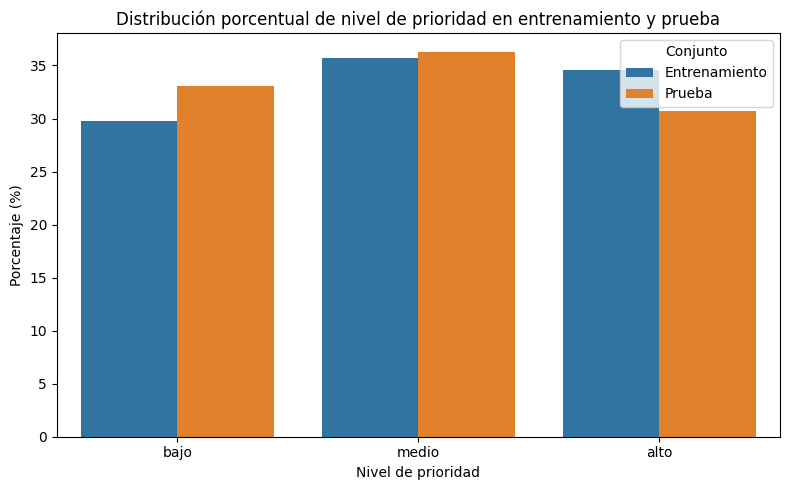

In [ ]:
dist_train = (y_train.value_counts(normalize=True) * 100).reset_index()
dist_train.columns = ["nivel_prioridad", "porcentaje"]
dist_train["conjunto"] = "Entrenamiento"

dist_test = (y_test.value_counts(normalize=True) * 100).reset_index()
dist_test.columns = ["nivel_prioridad", "porcentaje"]
dist_test["conjunto"] = "Prueba"

df_dist = pd.concat([dist_train, dist_test], ignore_index=True)

orden_prioridad = ["bajo", "medio", "alto"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_dist,
    x="nivel_prioridad",
    y="porcentaje",
    hue="conjunto",
    order=orden_prioridad
)

plt.title("Distribución porcentual de nivel de prioridad en entrenamiento y prueba")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Porcentaje (%)")
plt.legend(title="Conjunto")
plt.tight_layout()
plt.savefig("dp_02_distribucion_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

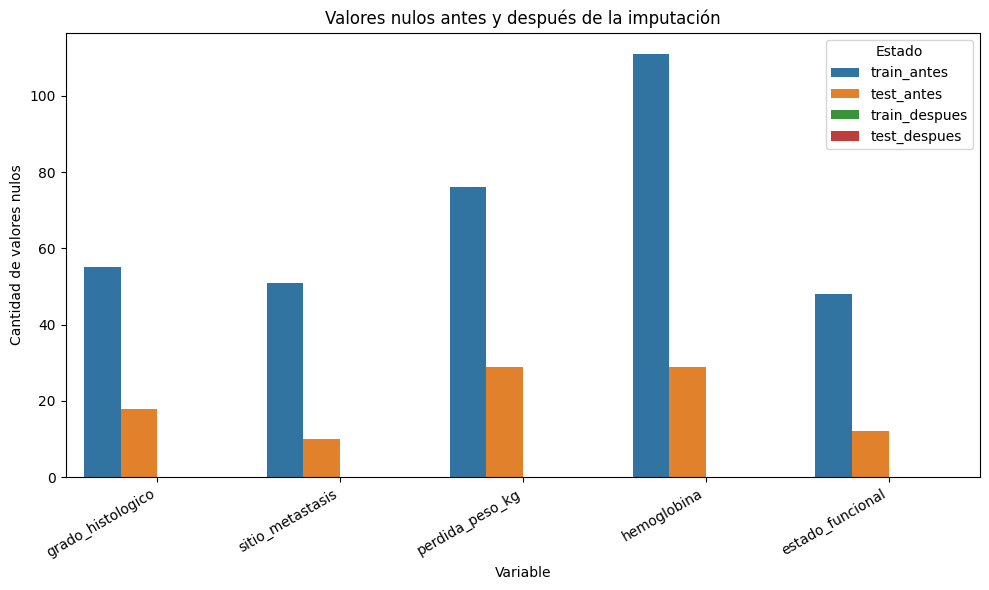

In [ ]:
nulos_train_antes = X_train_raw.isnull().sum()
nulos_test_antes = X_test_raw.isnull().sum()
nulos_train_despues = X_train_prep.isnull().sum()
nulos_test_despues = X_test_prep.isnull().sum()

variables_con_nulos = nulos_train_antes[
    (nulos_train_antes > 0) | (nulos_test_antes > 0)
].index.tolist()

df_nulos = pd.DataFrame({
    "variable": variables_con_nulos,
    "train_antes": nulos_train_antes[variables_con_nulos].values,
    "test_antes": nulos_test_antes[variables_con_nulos].values,
    "train_despues": nulos_train_despues[variables_con_nulos].values,
    "test_despues": nulos_test_despues[variables_con_nulos].values
})

df_nulos_largo = df_nulos.melt(
    id_vars="variable",
    var_name="estado",
    value_name="cantidad_nulos"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_nulos_largo,
    x="variable",
    y="cantidad_nulos",
    hue="estado"
)

plt.title("Valores nulos antes y después de la imputación")
plt.xlabel("Variable")
plt.ylabel("Cantidad de valores nulos")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Estado")
plt.tight_layout()
plt.savefig("dp_02_nulos_antes_despues_imputacion.png", dpi=300, bbox_inches="tight")
plt.show()

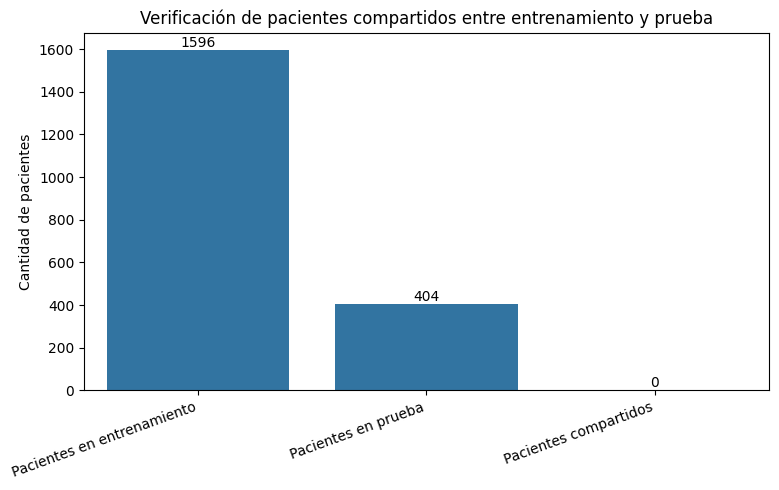

Pacientes compartidos entre train y test: 0


In [ ]:
pacientes_train = set(grupos_train)
pacientes_test = set(grupos_test)
pacientes_compartidos = pacientes_train.intersection(pacientes_test)

df_pacientes = pd.DataFrame({
    "categoria": [
        "Pacientes en entrenamiento",
        "Pacientes en prueba",
        "Pacientes compartidos"
    ],
    "cantidad": [
        len(pacientes_train),
        len(pacientes_test),
        len(pacientes_compartidos)
    ]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_pacientes,
    x="categoria",
    y="cantidad"
)

plt.title("Verificación de pacientes compartidos entre entrenamiento y prueba")
plt.xlabel("")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig("dp_02_pacientes_compartidos_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

print("Pacientes compartidos entre train y test:", len(pacientes_compartidos))

# Análisis DP-02: División train/test y manejo de valores nulos

En la etapa DP-02 se realizó la división del dataset en conjunto de entrenamiento y conjunto de prueba, manteniendo la estructura de variables obtenida en la etapa anterior. El conjunto de entrenamiento quedó conformado por **3999 registros y 34 variables predictoras**, mientras que el conjunto de prueba quedó conformado por **1001 registros y 34 variables predictoras**. Esta división mantiene aproximadamente una proporción de 80% para entrenamiento y 20% para prueba.

Un punto importante es que la división se realizó considerando el `paciente_id` como grupo. Esto permite evitar que evaluaciones de un mismo paciente aparezcan al mismo tiempo en entrenamiento y prueba. El resultado fue correcto, ya que se obtuvo **0 pacientes repetidos entre train y test**. Esto es muy importante porque reduce el riesgo de fuga de información y permite evaluar el modelo de una forma más realista.

La distribución de clases también se mantuvo relativamente equilibrada en ambos conjuntos. En entrenamiento, la clase `medio` representa **35.68%**, `alto` **34.58%** y `bajo` **29.73%**. En prueba, la clase `medio` representa **36.26%**, `bajo` **33.07%** y `alto` **30.67%**. Aunque no son idénticas, las proporciones siguen siendo cercanas y conservan las tres clases de la variable objetivo.

Respecto a los valores nulos, antes de la imputación se identificaron datos faltantes en cinco variables: `hemoglobina`, `perdida_peso_kg`, `grado_histologico`, `sitio_metastasis` y `estado_funcional`. En el conjunto de entrenamiento, los mayores nulos estuvieron en `hemoglobina` con **111 registros**, seguido de `perdida_peso_kg` con **76 registros**. En el conjunto de prueba, `hemoglobina` y `perdida_peso_kg` presentaron **29 nulos** cada una.

Para las variables numéricas se aplicó imputación con la mediana calculada únicamente en el conjunto de entrenamiento. Las medianas utilizadas fueron: `dias_desde_diagnostico` = **59.0**, `dias_en_albergue` = **19.0**, `edad` = **63.0**, `ganglios_afectados` = **2.0**, `perdida_peso_kg` = **5.8** y `hemoglobina` = **11.9**. Esta decisión evita usar información del conjunto de prueba durante la preparación del modelo.

Para las variables categóricas se imputaron los valores faltantes con una categoría especial, como `desconocido`, y en el caso de `sitio_metastasis` se mantuvo una regla lógica basada en la variable `metastasis`. Esto permite conservar coherencia clínica y evitar eliminar registros útiles.

Después de la imputación, se verificó que no quedaran valores nulos en ninguno de los conjuntos. Tanto `X_train_prep` como `X_test_prep` quedaron con **0 valores nulos**, lo cual confirma que la etapa de tratamiento de datos faltantes fue completada correctamente.

# Conclusión DP-02

La etapa DP-02 permitió dividir correctamente el dataset en entrenamiento y prueba, evitando que un mismo paciente aparezca en ambos conjuntos. Además, se mantuvo una distribución razonablemente balanceada de las clases `bajo`, `medio` y `alto`. También se trataron correctamente los valores nulos mediante imputación, usando la mediana para variables numéricas y categorías especiales para variables categóricas. Al finalizar la etapa, los conjuntos de entrenamiento y prueba quedaron libres de valores nulos y listos para continuar con la codificación de variables categóricas.



## DP-03: Clasificación de variables según técnica de preprocesamiento

In [ ]:
print("Dimensiones actuales de X_train_prep:")
print(X_train_prep.shape)

print("\nDimensiones actuales de X_test_prep:")
print(X_test_prep.shape)

Dimensiones actuales de X_train_prep:
(3999, 34)

Dimensiones actuales de X_test_prep:
(1001, 34)


In [ ]:
variables_numericas = [
    "dias_desde_diagnostico",
    "dias_en_albergue",
    "edad",
    "ganglios_afectados",
    "perdida_peso_kg",
    "hemoglobina"
]

print("Variables numéricas:")
print(variables_numericas)
print("Cantidad:", len(variables_numericas))

Variables numéricas:
['dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'ganglios_afectados', 'perdida_peso_kg', 'hemoglobina']
Cantidad: 6


In [ ]:
variables_binarias = [
    "viaja_desde_provincia",
    "acompanante",
    "metastasis",
    "anemia",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "dificultad_alimentarse",
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos"
]

print("Variables binarias:")
print(variables_binarias)
print("Cantidad:", len(variables_binarias))

Variables binarias:
['viaja_desde_provincia', 'acompanante', 'metastasis', 'anemia', 'vomitos_frecuentes', 'sangrado_digestivo', 'dificultad_alimentarse', 'requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos']
Cantidad: 11


In [ ]:
variables_ordinales = [
    "grupo_edad",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "estado_nutricional",
    "dolor",
    "fatiga",
    "comorbilidades",
    "estado_funcional"
]

print("Variables ordinales:")
print(variables_ordinales)
print("Cantidad:", len(variables_ordinales))

Variables ordinales:
['grupo_edad', 'nivel_vulnerabilidad', 'dificultad_acceso_salud', 'estadio', 'grado_histologico', 'profundidad_tumor', 'estado_nutricional', 'dolor', 'fatiga', 'comorbilidades', 'estado_funcional']
Cantidad: 11


In [ ]:
variables_nominales = [
    "sexo",
    "region_procedencia",
    "zona_procedencia",
    "tipo_histologico",
    "sitio_metastasis",
    "tratamiento_principal"
]

print("Variables nominales:")
print(variables_nominales)
print("Cantidad:", len(variables_nominales))

Variables nominales:
['sexo', 'region_procedencia', 'zona_procedencia', 'tipo_histologico', 'sitio_metastasis', 'tratamiento_principal']
Cantidad: 6


In [ ]:
variables_asignadas = (
    variables_numericas +
    variables_binarias +
    variables_ordinales +
    variables_nominales
)

columnas_modelo = X_train_prep.columns.tolist()

variables_no_asignadas = set(columnas_modelo) - set(variables_asignadas)
variables_extra = set(variables_asignadas) - set(columnas_modelo)

variables_repetidas = pd.Series(variables_asignadas).value_counts()
variables_repetidas = variables_repetidas[variables_repetidas > 1]

print("Total de columnas en X_train_prep:", len(columnas_modelo))
print("Total de variables asignadas:", len(variables_asignadas))

print("\nVariables no asignadas:")
print(variables_no_asignadas)

print("\nVariables asignadas que no existen en X_train_prep:")
print(variables_extra)

print("\nVariables repetidas:")
display(variables_repetidas)

Total de columnas en X_train_prep: 34
Total de variables asignadas: 34

Variables no asignadas:
set()

Variables asignadas que no existen en X_train_prep:
set()

Variables repetidas:


,count


In [ ]:
variables_categoricas = variables_binarias + variables_ordinales + variables_nominales

for col in variables_categoricas:
    print(f"\n--- {col} ---")
    print(sorted(X_train_prep[col].astype(str).unique()))


--- viaja_desde_provincia ---
['no', 'si']

--- acompanante ---
['no', 'si']

--- metastasis ---
['no', 'si']

--- anemia ---
['no', 'si']

--- vomitos_frecuentes ---
['no', 'si']

--- sangrado_digestivo ---
['no', 'si']

--- dificultad_alimentarse ---
['no', 'si']

--- requiere_cirugia ---
['no', 'si']

--- requiere_quimioterapia ---
['no', 'si']

--- requiere_soporte_nutricional ---
['no', 'si']

--- requiere_cuidados_paliativos ---
['no', 'si']

--- grupo_edad ---
['adulto', 'adulto_joven', 'adulto_mayor', 'nino_adolescente']

--- nivel_vulnerabilidad ---
['alto', 'medio', 'muy_alto']

--- dificultad_acceso_salud ---
['alta', 'baja', 'media']

--- estadio ---
['0', 'I', 'II', 'III', 'IV']

--- grado_histologico ---
['G1', 'G2', 'G3', 'G4', 'desconocido']

--- profundidad_tumor ---
['enfermedad_diseminada', 'invasion_local', 'mucosa', 'muscular', 'serosa', 'submucosa']

--- estado_nutricional ---
['adecuado', 'desnutricion', 'riesgo']

--- dolor ---
['alto', 'bajo', 'medio']

--- fa

In [ ]:
categorias_nuevas_test = {}

for col in variables_categoricas:
    categorias_train = set(X_train_prep[col].astype(str).unique())
    categorias_test = set(X_test_prep[col].astype(str).unique())

    nuevas = categorias_test - categorias_train

    if len(nuevas) > 0:
        categorias_nuevas_test[col] = nuevas

print("Categorías nuevas en test que no aparecen en train:")
print(categorias_nuevas_test)

Categorías nuevas en test que no aparecen en train:
{}


In [ ]:
df_tipos_variables = pd.DataFrame({
    "tipo_variable": [
        "Numéricas",
        "Binarias",
        "Ordinales",
        "Nominales"
    ],
    "tecnica_preprocesamiento": [
        "Normalización o estandarización",
        "Codificación 0/1",
        "Codificación ordinal",
        "One-Hot Encoding"
    ],
    "cantidad_variables": [
        len(variables_numericas),
        len(variables_binarias),
        len(variables_ordinales),
        len(variables_nominales)
    ]
})

display(df_tipos_variables)

,tipo_variable,tecnica_preprocesamiento,cantidad_variables
0,Numéricas,Normalización o estandarización,6
1,Binarias,Codificación 0/1,11
2,Ordinales,Codificación ordinal,11
3,Nominales,One-Hot Encoding,6


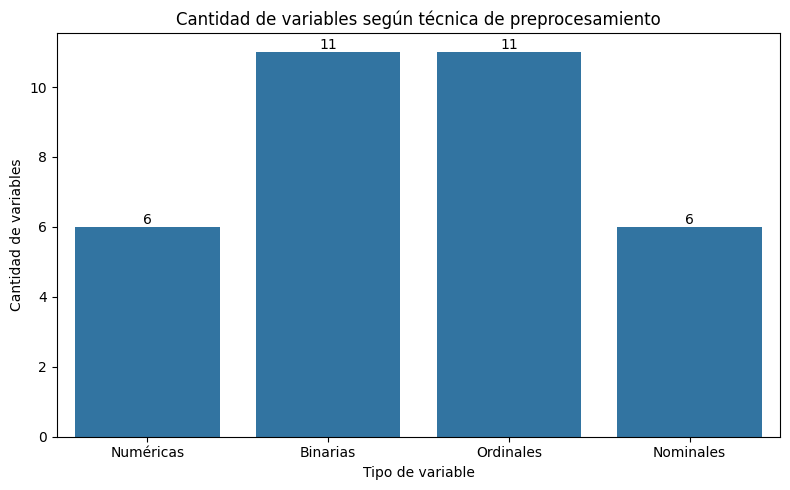

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_tipos_variables,
    x="tipo_variable",
    y="cantidad_variables"
)

plt.title("Cantidad de variables según técnica de preprocesamiento")
plt.xlabel("Tipo de variable")
plt.ylabel("Cantidad de variables")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig("dp_03_variables_por_tipo_preprocesamiento.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis DP-03: Clasificación de variables según técnica de preprocesamiento

En la etapa DP-03 se clasificaron las **34 variables predictoras** según el tipo de transformación que recibirán en las siguientes fases de preparación. Esta clasificación es necesaria porque no todas las variables pueden tratarse de la misma forma: algunas son numéricas, otras son binarias, otras tienen un orden lógico y otras son categorías sin orden natural.

El conjunto de entrenamiento mantiene **3999 registros y 34 variables**, mientras que el conjunto de prueba mantiene **1001 registros y 34 variables**. Esto confirma que en esta etapa no se eliminaron ni agregaron columnas, sino que únicamente se organizó el tratamiento que recibirá cada variable.

Las variables quedaron distribuidas de la siguiente manera:

| Tipo de variable | Técnica de preprocesamiento     | Cantidad |
| ---------------- | ------------------------------- | -------: |
| Numéricas        | Normalización o estandarización |        6 |
| Binarias         | Codificación 0/1                |       11 |
| Ordinales        | Codificación ordinal            |       11 |
| Nominales        | One-Hot Encoding                |        6 |

Además, la validación fue correcta: el total de variables asignadas fue **34**, igual al número de columnas de `X_train_prep`. No quedaron variables sin asignar, no se detectaron variables repetidas y no existieron variables asignadas que no estén presentes en el dataset.

También se verificaron las categorías presentes en el conjunto de entrenamiento. Las variables binarias tienen únicamente valores `si` y `no`, lo cual permite aplicar una codificación directa a 0 y 1. Las variables ordinales tienen categorías con orden lógico, como `bajo`, `medio`, `alto`, o niveles clínicos como `0`, `I`, `II`, `III`, `IV`. Las variables nominales, como `sexo`, `region_procedencia`, `tipo_histologico` y `tratamiento_principal`, no tienen un orden natural, por lo que se codificarán posteriormente mediante One-Hot Encoding.

Finalmente, se verificó que no existan categorías nuevas en el conjunto de prueba que no aparezcan en entrenamiento. El resultado fue `{}`, lo cual es favorable porque reduce problemas durante la codificación.

# Conclusión DP-03

La etapa DP-03 permitió organizar correctamente las variables predictoras según la técnica de preprocesamiento más adecuada. Esta clasificación es importante porque evita aplicar transformaciones incorrectas, como usar codificación ordinal en variables sin orden natural o aplicar One-Hot Encoding a variables que sí tienen jerarquía clínica. Al finalizar esta etapa, las 34 variables predictoras quedaron completamente clasificadas y listas para iniciar la codificación.







## DP-04: Codificación de variables binarias

In [ ]:
variables_binarias = [
    "viaja_desde_provincia",
    "acompanante",
    "metastasis",
    "anemia",
    "vomitos_frecuentes",
    "sangrado_digestivo",
    "dificultad_alimentarse",
    "requiere_cirugia",
    "requiere_quimioterapia",
    "requiere_soporte_nutricional",
    "requiere_cuidados_paliativos"
]

print("Variables binarias a codificar:")
print(variables_binarias)

Variables binarias a codificar:
['viaja_desde_provincia', 'acompanante', 'metastasis', 'anemia', 'vomitos_frecuentes', 'sangrado_digestivo', 'dificultad_alimentarse', 'requiere_cirugia', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'requiere_cuidados_paliativos']


In [ ]:
for col in variables_binarias:
    print(f"\n--- {col} ---")
    print("Train:", sorted(X_train_prep[col].astype(str).unique()))
    print("Test:", sorted(X_test_prep[col].astype(str).unique()))


--- viaja_desde_provincia ---
Train: ['no', 'si']
Test: ['no', 'si']

--- acompanante ---
Train: ['no', 'si']
Test: ['no', 'si']

--- metastasis ---
Train: ['no', 'si']
Test: ['no', 'si']

--- anemia ---
Train: ['no', 'si']
Test: ['no', 'si']

--- vomitos_frecuentes ---
Train: ['no', 'si']
Test: ['no', 'si']

--- sangrado_digestivo ---
Train: ['no', 'si']
Test: ['no', 'si']

--- dificultad_alimentarse ---
Train: ['no', 'si']
Test: ['no', 'si']

--- requiere_cirugia ---
Train: ['no', 'si']
Test: ['no', 'si']

--- requiere_quimioterapia ---
Train: ['no', 'si']
Test: ['no', 'si']

--- requiere_soporte_nutricional ---
Train: ['no', 'si']
Test: ['no', 'si']

--- requiere_cuidados_paliativos ---
Train: ['no', 'si']
Test: ['no', 'si']


In [ ]:
mapa_binario = {
    "no": 0,
    "si": 1
}

for col in variables_binarias:
    X_train_prep[col] = X_train_prep[col].map(mapa_binario)
    X_test_prep[col] = X_test_prep[col].map(mapa_binario)

In [ ]:

print("Valores después de codificar en train:")
for col in variables_binarias:
    print(f"{col}: {sorted(X_train_prep[col].dropna().unique())}")

print("\nValores después de codificar en test:")
for col in variables_binarias:
    print(f"{col}: {sorted(X_test_prep[col].dropna().unique())}")

print("\nNulos generados en train después de codificación:")
display(X_train_prep[variables_binarias].isnull().sum())

print("\nNulos generados en test después de codificación:")
display(X_test_prep[variables_binarias].isnull().sum())

Valores después de codificar en train:
viaja_desde_provincia: [np.int64(0), np.int64(1)]
acompanante: [np.int64(0), np.int64(1)]
metastasis: [np.int64(0), np.int64(1)]
anemia: [np.int64(0), np.int64(1)]
vomitos_frecuentes: [np.int64(0), np.int64(1)]
sangrado_digestivo: [np.int64(0), np.int64(1)]
dificultad_alimentarse: [np.int64(0), np.int64(1)]
requiere_cirugia: [np.int64(0), np.int64(1)]
requiere_quimioterapia: [np.int64(0), np.int64(1)]
requiere_soporte_nutricional: [np.int64(0), np.int64(1)]
requiere_cuidados_paliativos: [np.int64(0), np.int64(1)]

Valores después de codificar en test:
viaja_desde_provincia: [np.int64(0), np.int64(1)]
acompanante: [np.int64(0), np.int64(1)]
metastasis: [np.int64(0), np.int64(1)]
anemia: [np.int64(0), np.int64(1)]
vomitos_frecuentes: [np.int64(0), np.int64(1)]
sangrado_digestivo: [np.int64(0), np.int64(1)]
dificultad_alimentarse: [np.int64(0), np.int64(1)]
requiere_cirugia: [np.int64(0), np.int64(1)]
requiere_quimioterapia: [np.int64(0), np.int64(1)

,0
viaja_desde_provincia,0
acompanante,0
metastasis,0
anemia,0
vomitos_frecuentes,0
sangrado_digestivo,0
dificultad_alimentarse,0
requiere_cirugia,0
requiere_quimioterapia,0
requiere_soporte_nutricional,0



Nulos generados en test después de codificación:


,0
viaja_desde_provincia,0
acompanante,0
metastasis,0
anemia,0
vomitos_frecuentes,0
sangrado_digestivo,0
dificultad_alimentarse,0
requiere_cirugia,0
requiere_quimioterapia,0
requiere_soporte_nutricional,0


In [ ]:

resumen_binarias = []

for col in variables_binarias:
    resumen_binarias.append({
        "variable": col,
        "valores_train": sorted(X_train_prep[col].dropna().unique()),
        "valores_test": sorted(X_test_prep[col].dropna().unique()),
        "nulos_train": X_train_prep[col].isnull().sum(),
        "nulos_test": X_test_prep[col].isnull().sum()
    })

df_resumen_binarias = pd.DataFrame(resumen_binarias)

display(df_resumen_binarias)

,variable,valores_train,valores_test,nulos_train,nulos_test
0,viaja_desde_provincia,"[0, 1]","[0, 1]",0,0
1,acompanante,"[0, 1]","[0, 1]",0,0
2,metastasis,"[0, 1]","[0, 1]",0,0
3,anemia,"[0, 1]","[0, 1]",0,0
4,vomitos_frecuentes,"[0, 1]","[0, 1]",0,0
5,sangrado_digestivo,"[0, 1]","[0, 1]",0,0
6,dificultad_alimentarse,"[0, 1]","[0, 1]",0,0
7,requiere_cirugia,"[0, 1]","[0, 1]",0,0
8,requiere_quimioterapia,"[0, 1]","[0, 1]",0,0
9,requiere_soporte_nutricional,"[0, 1]","[0, 1]",0,0


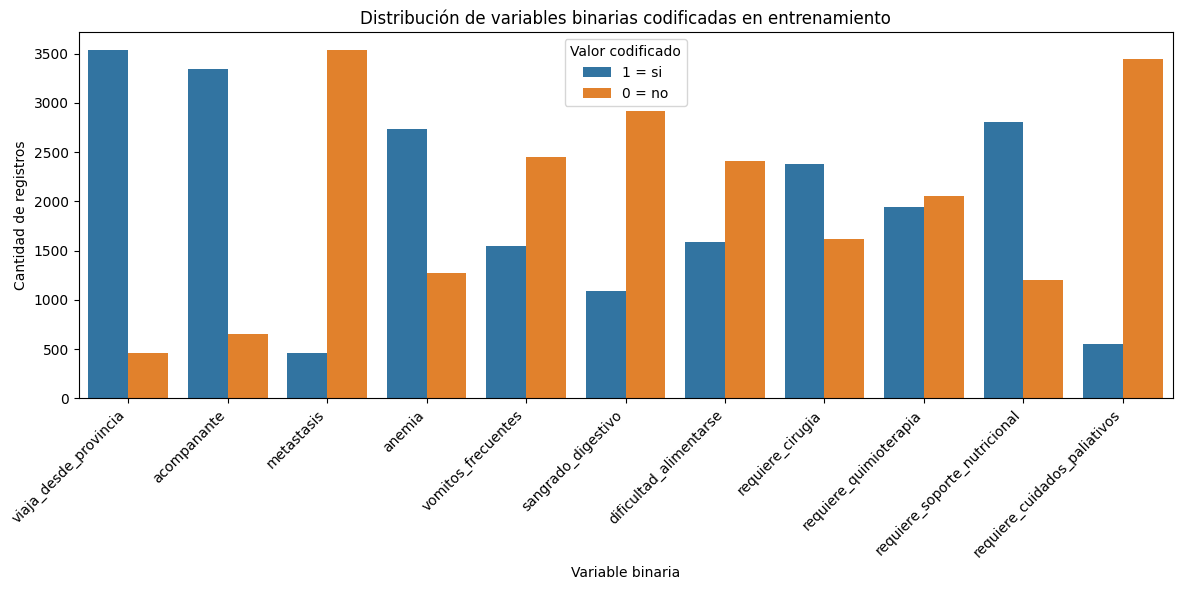

In [ ]:
df_binarias_plot = X_train_prep[variables_binarias].melt(
    var_name="variable",
    value_name="valor"
)

df_binarias_plot["valor"] = df_binarias_plot["valor"].map({
    0: "0 = no",
    1: "1 = si"
})

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_binarias_plot,
    x="variable",
    hue="valor"
)

plt.title("Distribución de variables binarias codificadas en entrenamiento")
plt.xlabel("Variable binaria")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Valor codificado")

plt.tight_layout()
plt.savefig("dp_04_variables_binarias_codificadas.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis DP-04: Codificación de variables binarias

La etapa DP-04 se realizó correctamente. Las 11 variables binarias tenían únicamente las categorías `si` y `no` tanto en entrenamiento como en prueba, por lo que fue adecuado aplicar una codificación directa:

```text
no = 0
si = 1
```

Después de la transformación, todas las variables binarias quedaron convertidas a valores numéricos `[0, 1]` en ambos conjuntos. Además, no se generaron valores nulos durante la codificación, lo cual confirma que no existían categorías inesperadas o mal escritas.

El gráfico generado permite observar la distribución de las variables binarias ya codificadas. Se aprecia que algunas variables tienen alta presencia del valor `1 = si`, como `viaja_desde_provincia`, `acompanante` y `requiere_soporte_nutricional`. En cambio, variables como `metastasis` y `requiere_cuidados_paliativos` tienen mayor presencia del valor `0 = no`, lo cual es coherente con lo observado en el EDA.

# Conclusión DP-04

La codificación binaria permitió transformar correctamente las variables de respuesta `si/no` a formato numérico, manteniendo su significado original y dejando los datos listos para continuar con la codificación ordinal.


## DP-05: Codificación de variables ordinales

In [ ]:
variables_ordinales = [
    "grupo_edad",
    "nivel_vulnerabilidad",
    "dificultad_acceso_salud",
    "estadio",
    "grado_histologico",
    "profundidad_tumor",
    "estado_nutricional",
    "dolor",
    "fatiga",
    "comorbilidades",
    "estado_funcional"
]

print("Variables ordinales a codificar:")
print(variables_ordinales)

Variables ordinales a codificar:
['grupo_edad', 'nivel_vulnerabilidad', 'dificultad_acceso_salud', 'estadio', 'grado_histologico', 'profundidad_tumor', 'estado_nutricional', 'dolor', 'fatiga', 'comorbilidades', 'estado_funcional']


In [ ]:
mapas_ordinales = {
    "grupo_edad": {
        "nino_adolescente": 0,
        "adulto_joven": 1,
        "adulto": 2,
        "adulto_mayor": 3
    },

    "nivel_vulnerabilidad": {
        "medio": 0,
        "alto": 1,
        "muy_alto": 2
    },

    "dificultad_acceso_salud": {
        "baja": 0,
        "media": 1,
        "alta": 2
    },

    "estadio": {
        "0": 0,
        "I": 1,
        "II": 2,
        "III": 3,
        "IV": 4
    },

    "grado_histologico": {
        "desconocido": -1,
        "G1": 1,
        "G2": 2,
        "G3": 3,
        "G4": 4
    },

    "profundidad_tumor": {
        "mucosa": 0,
        "submucosa": 1,
        "muscular": 2,
        "serosa": 3,
        "invasion_local": 4,
        "enfermedad_diseminada": 5
    },

    "estado_nutricional": {
        "adecuado": 0,
        "riesgo": 1,
        "desnutricion": 2
    },

    "dolor": {
        "bajo": 0,
        "medio": 1,
        "alto": 2
    },

    "fatiga": {
        "baja": 0,
        "media": 1,
        "alta": 2
    },

    "comorbilidades": {
        "ninguna": 0,
        "una": 1,
        "multiples": 2
    },

    "estado_funcional": {
        "desconocido": -1,
        "bueno": 0,
        "limitado": 1,
        "dependiente": 2
    }
}

In [ ]:
filas_mapeo = []

for variable, mapa in mapas_ordinales.items():
    for categoria, valor in mapa.items():
        filas_mapeo.append({
            "variable": variable,
            "categoria_original": categoria,
            "valor_codificado": valor
        })

df_mapeo_ordinal = pd.DataFrame(filas_mapeo)

display(df_mapeo_ordinal)

,variable,categoria_original,valor_codificado
0,grupo_edad,nino_adolescente,0
1,grupo_edad,adulto_joven,1
2,grupo_edad,adulto,2
3,grupo_edad,adulto_mayor,3
4,nivel_vulnerabilidad,medio,0
5,nivel_vulnerabilidad,alto,1
6,nivel_vulnerabilidad,muy_alto,2
7,dificultad_acceso_salud,baja,0
8,dificultad_acceso_salud,media,1
9,dificultad_acceso_salud,alta,2


In [ ]:
for col in variables_ordinales:
    X_train_prep[col] = X_train_prep[col].map(mapas_ordinales[col])
    X_test_prep[col] = X_test_prep[col].map(mapas_ordinales[col])

In [ ]:
print("Valores después de codificar en train:")
for col in variables_ordinales:
    print(f"{col}: {sorted(X_train_prep[col].dropna().unique())}")

print("\nValores después de codificar en test:")
for col in variables_ordinales:
    print(f"{col}: {sorted(X_test_prep[col].dropna().unique())}")

print("\nNulos generados en variables ordinales train:")
display(X_train_prep[variables_ordinales].isnull().sum())

print("\nNulos generados en variables ordinales test:")
display(X_test_prep[variables_ordinales].isnull().sum())

Valores después de codificar en train:
grupo_edad: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
nivel_vulnerabilidad: [np.int64(0), np.int64(1), np.int64(2)]
dificultad_acceso_salud: [np.int64(0), np.int64(1), np.int64(2)]
estadio: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
grado_histologico: [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
profundidad_tumor: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
estado_nutricional: [np.int64(0), np.int64(1), np.int64(2)]
dolor: [np.int64(0), np.int64(1), np.int64(2)]
fatiga: [np.int64(0), np.int64(1), np.int64(2)]
comorbilidades: [np.int64(0), np.int64(1), np.int64(2)]
estado_funcional: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]

Valores después de codificar en test:
grupo_edad: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
nivel_vulnerabilidad: [np.int64(0), np.int64(1), np.int64(2)]
dificultad_acceso_salud: [np.int64(0), np.int64(1), np.int64(

,0
grupo_edad,0
nivel_vulnerabilidad,0
dificultad_acceso_salud,0
estadio,0
grado_histologico,0
profundidad_tumor,0
estado_nutricional,0
dolor,0
fatiga,0
comorbilidades,0



Nulos generados en variables ordinales test:


,0
grupo_edad,0
nivel_vulnerabilidad,0
dificultad_acceso_salud,0
estadio,0
grado_histologico,0
profundidad_tumor,0
estado_nutricional,0
dolor,0
fatiga,0
comorbilidades,0


In [ ]:
validacion_ordinal = []

for col in variables_ordinales:
    validacion_ordinal.append({
        "variable": col,
        "valores_train": sorted(X_train_prep[col].dropna().unique()),
        "valores_test": sorted(X_test_prep[col].dropna().unique()),
        "nulos_train": X_train_prep[col].isnull().sum(),
        "nulos_test": X_test_prep[col].isnull().sum()
    })

df_validacion_ordinal = pd.DataFrame(validacion_ordinal)

display(df_validacion_ordinal)

,variable,valores_train,valores_test,nulos_train,nulos_test
0,grupo_edad,"[0, 1, 2, 3]","[0, 1, 2, 3]",0,0
1,nivel_vulnerabilidad,"[0, 1, 2]","[0, 1, 2]",0,0
2,dificultad_acceso_salud,"[0, 1, 2]","[0, 1, 2]",0,0
3,estadio,"[0, 1, 2, 3, 4]","[0, 1, 2, 3, 4]",0,0
4,grado_histologico,"[-1, 1, 2, 3, 4]","[-1, 1, 2, 3, 4]",0,0
5,profundidad_tumor,"[0, 1, 2, 3, 4, 5]","[0, 1, 2, 3, 4, 5]",0,0
6,estado_nutricional,"[0, 1, 2]","[0, 1, 2]",0,0
7,dolor,"[0, 1, 2]","[0, 1, 2]",0,0
8,fatiga,"[0, 1, 2]","[0, 1, 2]",0,0
9,comorbilidades,"[0, 1, 2]","[0, 1, 2]",0,0


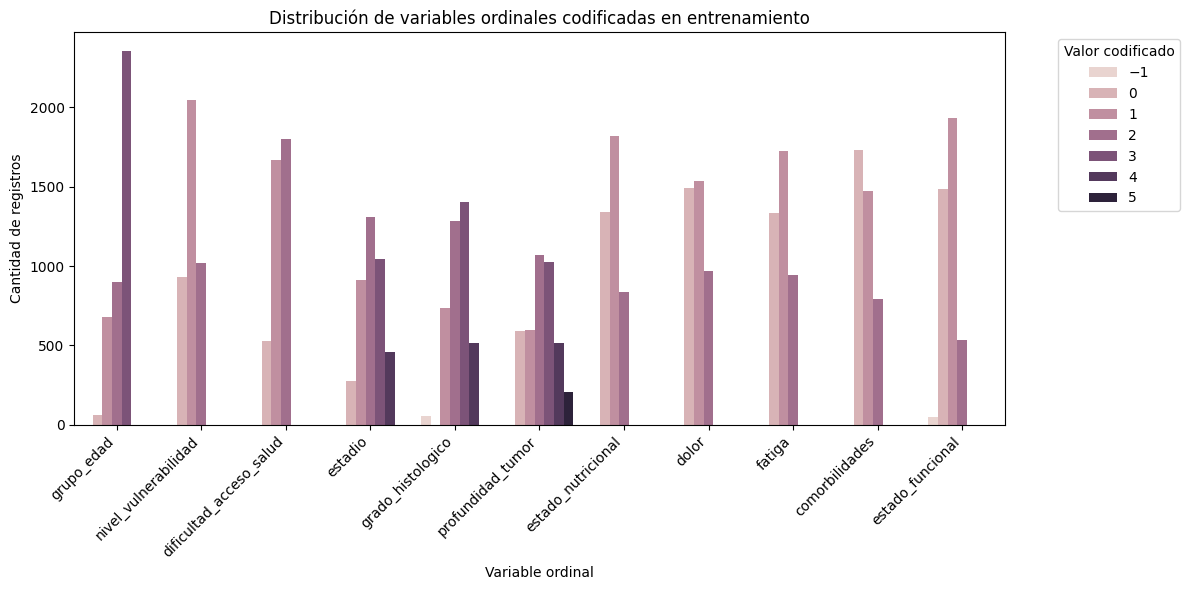

In [ ]:
df_ordinal_plot = X_train_prep[variables_ordinales].melt(
    var_name="variable",
    value_name="valor_codificado"
)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_ordinal_plot,
    x="variable",
    hue="valor_codificado"
)

plt.title("Distribución de variables ordinales codificadas en entrenamiento")
plt.xlabel("Variable ordinal")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Valor codificado", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("dp_05_variables_ordinales_codificadas.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis DP-05: Codificación de variables ordinales

En la etapa DP-05 se realizó la codificación ordinal de las variables categóricas que presentan un orden lógico, clínico o jerárquico. Esta transformación fue necesaria porque los modelos de Machine Learning requieren datos numéricos para procesar las variables predictoras. A diferencia de las variables nominales, las variables ordinales sí tienen una relación de menor a mayor intensidad, severidad o progresión, por lo que no sería adecuado aplicarles One-Hot Encoding de forma principal, ya que se perdería esa jerarquía.

Las variables codificadas fueron `grupo_edad`, `nivel_vulnerabilidad`, `dificultad_acceso_salud`, `estadio`, `grado_histologico`, `profundidad_tumor`, `estado_nutricional`, `dolor`, `fatiga`, `comorbilidades` y `estado_funcional`. Para cada una se definió un mapeo numérico respetando su significado. Por ejemplo, `estadio` se codificó desde `0` hasta `4`, siguiendo la progresión clínica de `0`, `I`, `II`, `III` y `IV`. De igual manera, `dolor` y `fatiga` se codificaron como `bajo = 0`, `medio/media = 1` y `alto/alta = 2`.

En las variables con categorías clínicas de severidad, la codificación también respetó el orden esperado. Por ejemplo, `profundidad_tumor` fue codificada desde `mucosa = 0` hasta `enfermedad_diseminada = 5`, lo cual representa una progresión del compromiso tumoral. En `estado_nutricional`, se asignó `adecuado = 0`, `riesgo = 1` y `desnutricion = 2`, reflejando el aumento del deterioro nutricional.

Para las categorías imputadas como `desconocido`, se utilizó el valor `-1` en variables como `grado_histologico` y `estado_funcional`. Esta decisión es adecuada porque permite diferenciar los datos faltantes o no registrados de las categorías clínicas reales. De esta manera, el modelo no interpreta `desconocido` como si fuera un grado histológico o un estado funcional válido dentro de la escala clínica.

Después de aplicar la codificación, se verificó que todas las variables ordinales tuvieran valores numéricos tanto en entrenamiento como en prueba. También se comprobó que no se generaron valores nulos durante la transformación. Esto confirma que todos los valores categóricos fueron correctamente reconocidos por los mapas de codificación definidos.

El gráfico de distribución de variables ordinales codificadas permite observar la frecuencia de cada valor numérico dentro del conjunto de entrenamiento. Este gráfico es útil para el informe porque muestra que las variables ya fueron convertidas a formato numérico y permite verificar visualmente la distribución de sus categorías codificadas.

# Conclusión DP-05

La codificación ordinal permitió transformar correctamente las variables categóricas con jerarquía clínica o lógica en valores numéricos ordenados. Esta transformación conserva información importante para el modelo, como la progresión del estadio clínico, el aumento del dolor, el deterioro nutricional, la severidad de la fatiga y el estado funcional del paciente. Además, la validación posterior confirmó que no se generaron valores nulos y que las codificaciones fueron consistentes en los conjuntos de entrenamiento y prueba. Con esta etapa, las variables ordinales quedaron listas para ser utilizadas en el proceso de modelado supervisado.


## DP-06: Codificación One-Hot Encoding de variables nominales

In [ ]:
variables_nominales = [
    "sexo",
    "region_procedencia",
    "zona_procedencia",
    "tipo_histologico",
    "sitio_metastasis",
    "tratamiento_principal"
]

print("Variables nominales a codificar con One-Hot Encoding:")
print(variables_nominales)

print("\nDimensiones antes del One-Hot Encoding:")
print("X_train_prep:", X_train_prep.shape)
print("X_test_prep:", X_test_prep.shape)

Variables nominales a codificar con One-Hot Encoding:
['sexo', 'region_procedencia', 'zona_procedencia', 'tipo_histologico', 'sitio_metastasis', 'tratamiento_principal']

Dimensiones antes del One-Hot Encoding:
X_train_prep: (3999, 34)
X_test_prep: (1001, 34)


In [ ]:
for col in variables_nominales:
    print(f"\n--- {col} ---")
    print("Train:", sorted(X_train_prep[col].astype(str).unique()))
    print("Test:", sorted(X_test_prep[col].astype(str).unique()))


--- sexo ---
Train: ['femenino', 'masculino']
Test: ['femenino', 'masculino']

--- region_procedencia ---
Train: ['Amazonas', 'Ancash', 'Apurimac', 'Ayacucho', 'Cajamarca', 'Cusco', 'Huancavelica', 'Ica', 'Junin', 'La Libertad', 'Lambayeque', 'Lima', 'Loreto', 'Madre de Dios', 'Piura', 'Puno', 'San Martin', 'Tumbes', 'Ucayali']
Test: ['Amazonas', 'Ancash', 'Apurimac', 'Ayacucho', 'Cajamarca', 'Cusco', 'Huancavelica', 'Ica', 'Junin', 'La Libertad', 'Lambayeque', 'Lima', 'Loreto', 'Madre de Dios', 'Piura', 'Puno', 'San Martin', 'Tumbes', 'Ucayali']

--- zona_procedencia ---
Train: ['costa', 'selva', 'sierra']
Test: ['costa', 'selva', 'sierra']

--- tipo_histologico ---
Train: ['adenocarcinoma_difuso', 'adenocarcinoma_intestinal', 'adenocarcinoma_mixto', 'otro']
Test: ['adenocarcinoma_difuso', 'adenocarcinoma_intestinal', 'adenocarcinoma_mixto', 'otro']

--- sitio_metastasis ---
Train: ['desconocido', 'higado', 'multiple', 'ninguno', 'peritoneo', 'pulmon']
Test: ['desconocido', 'higado',

In [ ]:
try:
    encoder_ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder_ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

encoder_ohe.fit(X_train_prep[variables_nominales])

train_ohe = encoder_ohe.transform(X_train_prep[variables_nominales])
test_ohe = encoder_ohe.transform(X_test_prep[variables_nominales])

columnas_ohe = encoder_ohe.get_feature_names_out(variables_nominales)

df_train_ohe = pd.DataFrame(
    train_ohe,
    columns=columnas_ohe,
    index=X_train_prep.index
)

df_test_ohe = pd.DataFrame(
    test_ohe,
    columns=columnas_ohe,
    index=X_test_prep.index
)

print("Cantidad de columnas generadas por One-Hot Encoding:")
print(len(columnas_ohe))

print("\nPrimeras columnas generadas:")
print(list(columnas_ohe[:20]))

Cantidad de columnas generadas por One-Hot Encoding:
40

Primeras columnas generadas:
['sexo_femenino', 'sexo_masculino', 'region_procedencia_Amazonas', 'region_procedencia_Ancash', 'region_procedencia_Apurimac', 'region_procedencia_Ayacucho', 'region_procedencia_Cajamarca', 'region_procedencia_Cusco', 'region_procedencia_Huancavelica', 'region_procedencia_Ica', 'region_procedencia_Junin', 'region_procedencia_La Libertad', 'region_procedencia_Lambayeque', 'region_procedencia_Lima', 'region_procedencia_Loreto', 'region_procedencia_Madre de Dios', 'region_procedencia_Piura', 'region_procedencia_Puno', 'region_procedencia_San Martin', 'region_procedencia_Tumbes']


In [ ]:
X_train_sin_nominales = X_train_prep.drop(columns=variables_nominales)
X_test_sin_nominales = X_test_prep.drop(columns=variables_nominales)

X_train_encoded = pd.concat(
    [X_train_sin_nominales, df_train_ohe],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test_sin_nominales, df_test_ohe],
    axis=1
)

print("Dimensiones después del One-Hot Encoding:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)

Dimensiones después del One-Hot Encoding:
X_train_encoded: (3999, 68)
X_test_encoded: (1001, 68)


In [ ]:
columnas_object_train = X_train_encoded.select_dtypes(include=["object", "category"]).columns.tolist()
columnas_object_test = X_test_encoded.select_dtypes(include=["object", "category"]).columns.tolist()

print("Columnas tipo object/category en X_train_encoded:")
print(columnas_object_train)

print("\nColumnas tipo object/category en X_test_encoded:")
print(columnas_object_test)

print("\nTotal de nulos en X_train_encoded:")
print(X_train_encoded.isnull().sum().sum())

print("\nTotal de nulos en X_test_encoded:")
print(X_test_encoded.isnull().sum().sum())

Columnas tipo object/category en X_train_encoded:
[]

Columnas tipo object/category en X_test_encoded:
[]

Total de nulos en X_train_encoded:
0

Total de nulos en X_test_encoded:
0


In [ ]:
conteo_ohe = []

for variable in variables_nominales:
    columnas_variable = [col for col in columnas_ohe if col.startswith(variable + "_")]

    conteo_ohe.append({
        "variable_nominal": variable,
        "categorias_train": X_train_prep[variable].nunique(),
        "columnas_generadas": len(columnas_variable)
    })

df_conteo_ohe = pd.DataFrame(conteo_ohe)

display(df_conteo_ohe)

,variable_nominal,categorias_train,columnas_generadas
0,sexo,2,2
1,region_procedencia,19,19
2,zona_procedencia,3,3
3,tipo_histologico,4,4
4,sitio_metastasis,6,6
5,tratamiento_principal,6,6


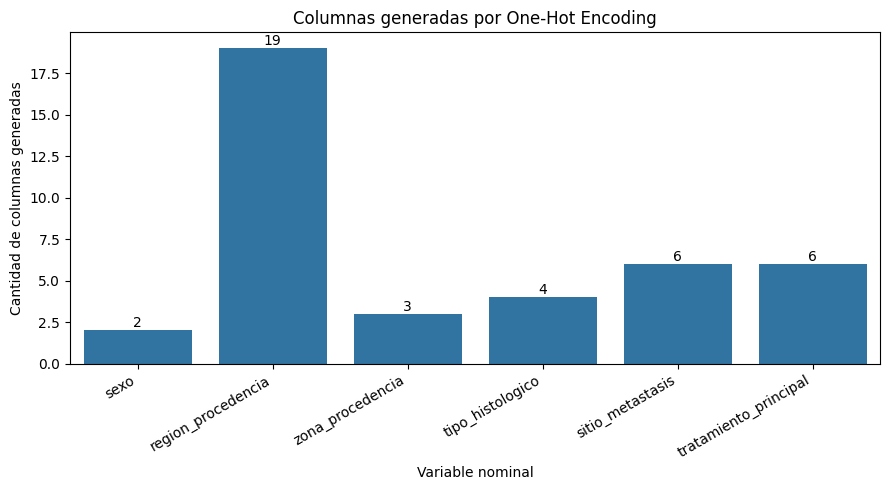

In [ ]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df_conteo_ohe,
    x="variable_nominal",
    y="columnas_generadas"
)

plt.title("Columnas generadas por One-Hot Encoding")
plt.xlabel("Variable nominal")
plt.ylabel("Cantidad de columnas generadas")
plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig("dp_06_columnas_generadas_onehot.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis DP-06: One-Hot Encoding de variables nominales

En la etapa DP-06 se aplicó **One-Hot Encoding** a las variables nominales: `sexo`, `region_procedencia`, `zona_procedencia`, `tipo_histologico`, `sitio_metastasis` y `tratamiento_principal`. Esta técnica fue adecuada porque estas variables no tienen un orden natural; por ejemplo, una región no es “mayor” o “menor” que otra, y un tipo histológico no debe representarse como una escala numérica ordinal.

Antes de aplicar la codificación, se verificó que las categorías presentes en entrenamiento y prueba fueran las mismas. Esto se cumplió correctamente en todas las variables nominales, lo que reduce el riesgo de inconsistencias durante la transformación. Además, se utilizó `handle_unknown="ignore"`, lo cual es una buena práctica porque evita errores si en un futuro aparece una categoría nueva en datos no vistos.

El One-Hot Encoding generó **40 nuevas columnas**. La variable que más columnas aportó fue `region_procedencia`, con **19 columnas**, debido a que contiene 19 regiones distintas. Luego, `sitio_metastasis` y `tratamiento_principal` generaron 6 columnas cada una, `tipo_histologico` generó 4, `zona_procedencia` generó 3 y `sexo` generó 2.

Después de reemplazar las 6 variables nominales por sus columnas codificadas, el conjunto de entrenamiento pasó de **34 variables** a **68 variables**, y el conjunto de prueba también quedó con **68 variables**. Esto confirma que ambos conjuntos mantienen la misma estructura después de la transformación.

También se validó que ya no quedaran columnas tipo `object` o `category`, y que no existieran valores nulos después de la codificación. Esto significa que el dataset ya quedó completamente numérico hasta esta etapa.
# Conclusión DP-06

La codificación One-Hot permitió transformar correctamente las variables nominales en columnas binarias, evitando imponer un orden artificial entre categorías. Al finalizar esta etapa, los conjuntos de entrenamiento y prueba quedaron con la misma cantidad de columnas, sin variables tipo texto y sin valores nulos. Con ello, el dataset queda listo para aplicar el escalamiento de variables numéricas.



## DP-07: Estandarización de variables numéricas

In [ ]:
variables_numericas = [
    "dias_desde_diagnostico",
    "dias_en_albergue",
    "edad",
    "ganglios_afectados",
    "perdida_peso_kg",
    "hemoglobina"
]

print("Variables numéricas a estandarizar:")
print(variables_numericas)

print("\nDimensiones antes del escalamiento:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)

Variables numéricas a estandarizar:
['dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'ganglios_afectados', 'perdida_peso_kg', 'hemoglobina']

Dimensiones antes del escalamiento:
X_train_encoded: (3999, 68)
X_test_encoded: (1001, 68)


In [ ]:
print("Estadísticos de variables numéricas antes del escalamiento - TRAIN:")
display(X_train_encoded[variables_numericas].describe().T)

print("\nEstadísticos de variables numéricas antes del escalamiento - TEST:")
display(X_test_encoded[variables_numericas].describe().T)

Estadísticos de variables numéricas antes del escalamiento - TRAIN:


,count,mean,std,min,25%,50%,75%,max
dias_desde_diagnostico,3999.0,59.562891,26.890426,1.0,40.0,59.0,78.00,147.0
dias_en_albergue,3999.0,22.393098,16.695535,0.0,9.0,19.0,33.00,74.0
edad,3999.0,58.719180,18.391670,15.0,45.0,63.0,72.00,90.0
ganglios_afectados,3999.0,3.665166,4.267056,0.0,0.0,2.0,6.00,17.0
perdida_peso_kg,3999.0,5.795824,2.974362,0.0,3.7,5.8,7.85,16.6
hemoglobina,3999.0,11.898400,1.137196,7.9,11.1,11.9,12.70,15.5



Estadísticos de variables numéricas antes del escalamiento - TEST:


,count,mean,std,min,25%,50%,75%,max
dias_desde_diagnostico,1001.0,59.912088,26.739526,4.0,40.0,61.0,78.0,144.0
dias_en_albergue,1001.0,21.799201,16.237877,0.0,8.0,19.0,32.0,74.0
edad,1001.0,57.943057,18.539627,15.0,45.0,62.0,71.0,90.0
ganglios_afectados,1001.0,3.379620,4.043729,0.0,0.0,2.0,5.0,17.0
perdida_peso_kg,1001.0,5.571229,2.898978,0.0,3.6,5.6,7.5,13.5
hemoglobina,1001.0,11.960140,1.126730,8.4,11.3,12.0,12.7,15.0


In [ ]:
scaler_numerico = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

scaler_numerico.fit(X_train_scaled[variables_numericas])

X_train_scaled[variables_numericas] = scaler_numerico.transform(
    X_train_scaled[variables_numericas]
)

X_test_scaled[variables_numericas] = scaler_numerico.transform(
    X_test_scaled[variables_numericas]
)

print("Escalamiento aplicado correctamente.")

Escalamiento aplicado correctamente.


In [ ]:
print("Estadísticos de variables numéricas después del escalamiento - TRAIN:")
display(X_train_scaled[variables_numericas].describe().T)

print("\nEstadísticos de variables numéricas después del escalamiento - TEST:")
display(X_test_scaled[variables_numericas].describe().T)

Estadísticos de variables numéricas después del escalamiento - TRAIN:


,count,mean,std,min,25%,50%,75%,max
dias_desde_diagnostico,3999.0,-5.330403e-18,1.000125,-2.178107,-0.727595,-0.020935,0.685724,3.252014
dias_en_albergue,3999.0,-8.706325e-17,1.000125,-1.341430,-0.802297,-0.203259,0.635393,3.091447
edad,3999.0,3.287082e-17,1.000125,-2.377416,-0.746039,0.232788,0.722201,1.701027
ganglios_afectados,3999.0,4.530843e-17,1.000125,-0.859052,-0.859052,-0.390287,0.547245,3.125457
perdida_peso_kg,3999.0,-1.528049e-16,1.000125,-1.948838,-0.704718,0.001404,0.690714,3.632889
hemoglobina,3999.0,4.211018e-16,1.000125,-3.516457,-0.702165,0.001407,0.704980,3.167485



Estadísticos de variables numéricas después del escalamiento - TEST:


,count,mean,std,min,25%,50%,75%,max
dias_desde_diagnostico,1001.0,0.012988,0.994513,-2.066529,-0.727595,0.053450,0.685724,3.140436
dias_en_albergue,1001.0,-0.035577,0.972710,-1.341430,-0.862200,-0.203259,0.575489,3.091447
edad,1001.0,-0.042205,1.008171,-2.377416,-0.746039,0.178409,0.667822,1.701027
ganglios_afectados,1001.0,-0.066927,0.947781,-0.859052,-0.859052,-0.390287,0.312862,3.125457
perdida_peso_kg,1001.0,-0.075520,0.974777,-1.948838,-0.738343,-0.065846,0.573027,2.590519
hemoglobina,1001.0,0.054298,0.990920,-3.076724,-0.526272,0.089354,0.704980,2.727752


In [ ]:
print("Dimensiones después del escalamiento:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTotal de nulos en X_train_scaled:")
print(X_train_scaled.isnull().sum().sum())

print("\nTotal de nulos en X_test_scaled:")
print(X_test_scaled.isnull().sum().sum())

print("\nColumnas tipo object/category en X_train_scaled:")
print(X_train_scaled.select_dtypes(include=["object", "category"]).columns.tolist())

print("\nColumnas tipo object/category en X_test_scaled:")
print(X_test_scaled.select_dtypes(include=["object", "category"]).columns.tolist())

Dimensiones después del escalamiento:
X_train_scaled: (3999, 68)
X_test_scaled: (1001, 68)

Total de nulos en X_train_scaled:
0

Total de nulos en X_test_scaled:
0

Columnas tipo object/category en X_train_scaled:
[]

Columnas tipo object/category en X_test_scaled:
[]


In [ ]:
df_parametros_scaler = pd.DataFrame({
    "variable": variables_numericas,
    "media_train_usada": scaler_numerico.mean_,
    "desviacion_train_usada": scaler_numerico.scale_
})

display(df_parametros_scaler)

,variable,media_train_usada,desviacion_train_usada
0,dias_desde_diagnostico,59.562891,26.887064
1,dias_en_albergue,22.393098,16.693447
2,edad,58.719180,18.389371
3,ganglios_afectados,3.665166,4.266523
4,perdida_peso_kg,5.795824,2.973990
5,hemoglobina,11.898400,1.137054


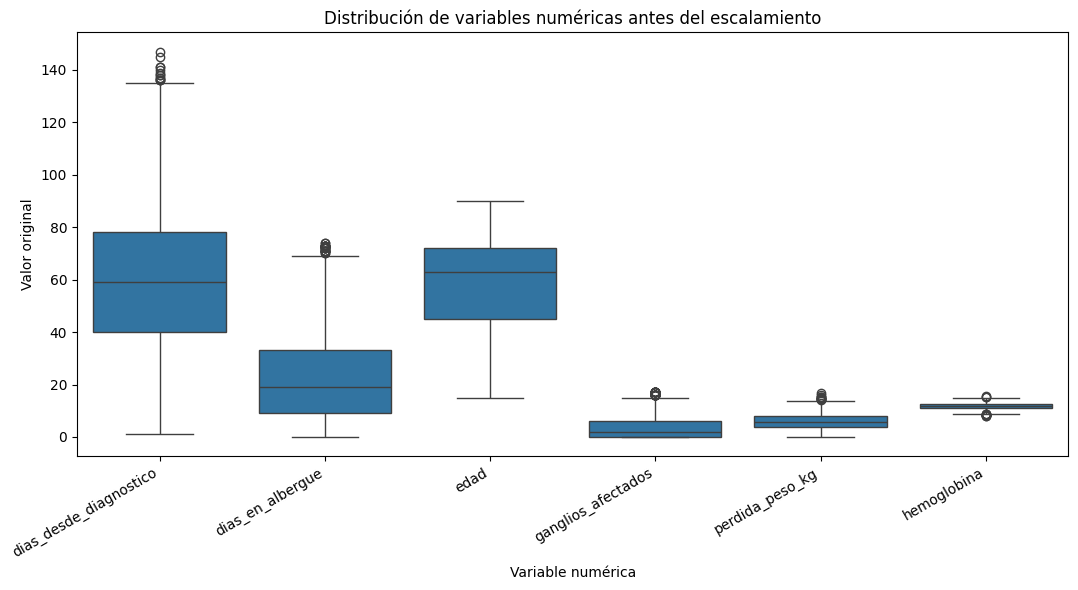

In [ ]:
df_num_antes = X_train_encoded[variables_numericas].melt(
    var_name="variable",
    value_name="valor"
)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_num_antes,
    x="variable",
    y="valor"
)

plt.title("Distribución de variables numéricas antes del escalamiento")
plt.xlabel("Variable numérica")
plt.ylabel("Valor original")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("dp_07_numericas_antes_escalamiento.png", dpi=300, bbox_inches="tight")
plt.show()

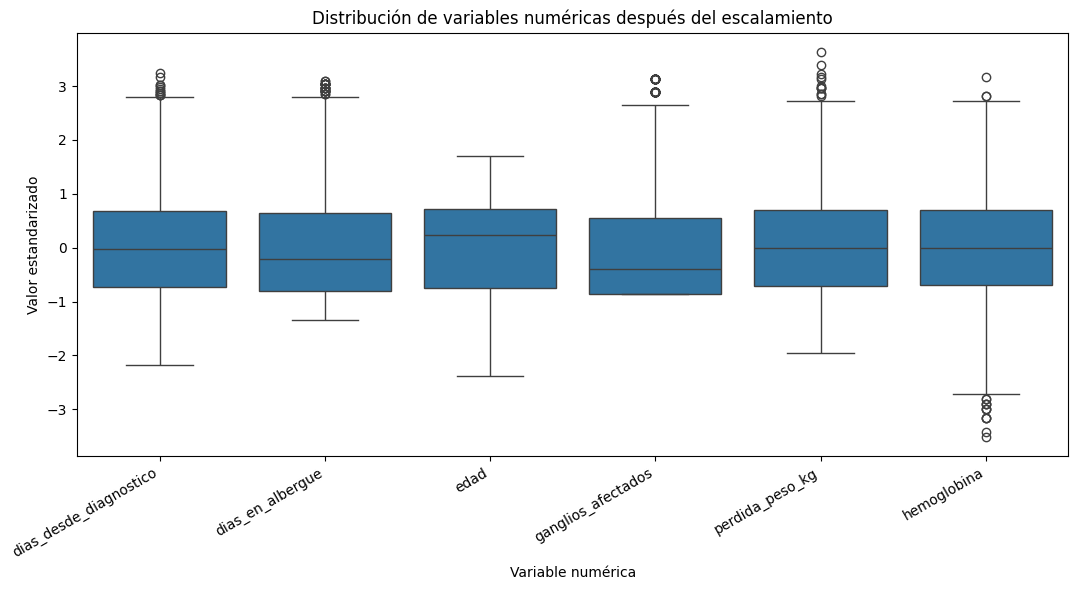

In [ ]:
df_num_despues = X_train_scaled[variables_numericas].melt(
    var_name="variable",
    value_name="valor_estandarizado"
)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_num_despues,
    x="variable",
    y="valor_estandarizado"
)

plt.title("Distribución de variables numéricas después del escalamiento")
plt.xlabel("Variable numérica")
plt.ylabel("Valor estandarizado")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("dp_07_numericas_despues_escalamiento.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis DP-07: Estandarización de variables numéricas

En la etapa DP-07 se aplicó **estandarización** a las variables numéricas del dataset: `dias_desde_diagnostico`, `dias_en_albergue`, `edad`, `ganglios_afectados`, `perdida_peso_kg` y `hemoglobina`. Esta transformación fue necesaria porque las variables numéricas estaban en escalas diferentes. Por ejemplo, `dias_desde_diagnostico` tenía valores entre 1 y 147, `edad` entre 15 y 90, mientras que `hemoglobina` tenía valores alrededor de 8 a 15. Si estas variables se dejan en escalas distintas, algunos modelos pueden dar más peso a las variables con valores numéricamente más grandes, aunque no necesariamente sean más importantes.

Antes del escalamiento, las variables numéricas presentaban rangos y dispersiones distintas. En el conjunto de entrenamiento, `dias_desde_diagnostico` tenía una media de **59.56** y una desviación estándar de **26.89**, mientras que `hemoglobina` tenía una media de **11.90** y una desviación estándar de **1.14**. Esta diferencia de escala justifica el uso de `StandardScaler`.

El escalador fue ajustado únicamente con el conjunto de entrenamiento, utilizando sus medias y desviaciones estándar. Esta decisión es correcta porque evita fuga de información desde el conjunto de prueba hacia el entrenamiento. Los parámetros usados por el escalador fueron, por ejemplo, media de **59.56** para `dias_desde_diagnostico`, **22.39** para `dias_en_albergue`, **58.72** para `edad`, **3.67** para `ganglios_afectados`, **5.80** para `perdida_peso_kg` y **11.90** para `hemoglobina`.

Después del escalamiento, las variables numéricas del conjunto de entrenamiento quedaron con medias cercanas a **0** y desviaciones estándar cercanas a **1**, lo cual confirma que la estandarización se aplicó correctamente. En el conjunto de prueba, las medias y desviaciones no son exactamente 0 y 1, lo cual es normal, porque el escalador no se ajustó con prueba, sino solo con entrenamiento.

Además, las dimensiones se conservaron correctamente: tanto `X_train_scaled` como `X_test_scaled` mantienen **68 columnas**. También se verificó que no existan valores nulos ni columnas tipo texto después del escalamiento. Esto confirma que el dataset ya está completamente numérico, limpio y con variables numéricas en una escala comparable.

# Conclusión DP-07

La estandarización permitió colocar las variables numéricas en una escala común, evitando que variables con rangos más amplios influyan de forma desproporcionada en los modelos. Al aplicar el escalamiento únicamente con los parámetros del conjunto de entrenamiento, se evitó fuga de información hacia el conjunto de prueba. Al finalizar esta etapa, los datos quedaron sin nulos, sin variables categóricas pendientes y con las variables numéricas correctamente normalizadas para el modelado.


## DP-08: Creación de nuevas variables clínicas y sociales

In [ ]:
X_train_fe = X_train_encoded.copy()
X_test_fe = X_test_encoded.copy()

print("Dimensiones antes de crear nuevas variables:")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe:", X_test_fe.shape)

Dimensiones antes de crear nuevas variables:
X_train_fe: (3999, 68)
X_test_fe: (1001, 68)


In [ ]:
def crear_features_severidad(df_temp):
    df_temp = df_temp.copy()

    df_temp["indice_avance_oncologico"] = (
        df_temp["estadio"] +
        df_temp["profundidad_tumor"] +
        df_temp["metastasis"] * 2 +
        df_temp["ganglios_afectados"]
    )

    df_temp["enfermedad_avanzada"] = (
        (df_temp["estadio"] >= 3) |
        (df_temp["metastasis"] == 1) |
        (df_temp["profundidad_tumor"] >= 4)
    ).astype(int)

    df_temp["alta_carga_ganglionar"] = (
        df_temp["ganglios_afectados"] >= 6
    ).astype(int)

    return df_temp


X_train_fe = crear_features_severidad(X_train_fe)
X_test_fe = crear_features_severidad(X_test_fe)

In [ ]:
def crear_features_nutricionales(df_temp):
    df_temp = df_temp.copy()

    df_temp["perdida_peso_alta"] = (
        df_temp["perdida_peso_kg"] >= 8
    ).astype(int)

    df_temp["hemoglobina_baja"] = (
        df_temp["hemoglobina"] < 11
    ).astype(int)

    df_temp["indice_deterioro_nutricional"] = (
        df_temp["estado_nutricional"] +
        df_temp["dificultad_alimentarse"] +
        df_temp["perdida_peso_alta"] +
        df_temp["requiere_soporte_nutricional"]
    )

    return df_temp


X_train_fe = crear_features_nutricionales(X_train_fe)
X_test_fe = crear_features_nutricionales(X_test_fe)

In [ ]:
def crear_features_sintomas(df_temp):
    df_temp = df_temp.copy()

    # Dolor alto
    df_temp["dolor_alto"] = (
        df_temp["dolor"] == 2
    ).astype(int)

    # Fatiga alta
    df_temp["fatiga_alta"] = (
        df_temp["fatiga"] == 2
    ).astype(int)

    # Conteo de síntomas relevantes
    df_temp["conteo_sintomas_relevantes"] = (
        df_temp["dolor_alto"] +
        df_temp["fatiga_alta"] +
        df_temp["vomitos_frecuentes"] +
        df_temp["sangrado_digestivo"] +
        df_temp["dificultad_alimentarse"] +
        df_temp["anemia"]
    )

    return df_temp


X_train_fe = crear_features_sintomas(X_train_fe)
X_test_fe = crear_features_sintomas(X_test_fe)

In [ ]:
def crear_features_tratamiento(df_temp):
    df_temp = df_temp.copy()

    # Cantidad de necesidades terapéuticas activas
    df_temp["conteo_necesidades_tratamiento"] = (
        df_temp["requiere_cirugia"] +
        df_temp["requiere_quimioterapia"] +
        df_temp["requiere_soporte_nutricional"] +
        df_temp["requiere_cuidados_paliativos"]
    )

    # Tratamiento de alta complejidad
    df_temp["tratamiento_alta_complejidad"] = (
        (df_temp["requiere_quimioterapia"] == 1) |
        (df_temp["requiere_cuidados_paliativos"] == 1)
    ).astype(int)

    return df_temp


X_train_fe = crear_features_tratamiento(X_train_fe)
X_test_fe = crear_features_tratamiento(X_test_fe)

In [ ]:
def crear_features_sociales(df_temp):
    df_temp = df_temp.copy()

    # Alta vulnerabilidad social
    df_temp["vulnerabilidad_social_alta"] = (
        (df_temp["nivel_vulnerabilidad"] >= 1) |
        (df_temp["dificultad_acceso_salud"] >= 2) |
        (df_temp["viaja_desde_provincia"] == 1)
    ).astype(int)

    # Riesgo social sin acompañante
    df_temp["riesgo_social_sin_acompanante"] = (
        (df_temp["acompanante"] == 0) &
        (df_temp["viaja_desde_provincia"] == 1)
    ).astype(int)

    return df_temp


X_train_fe = crear_features_sociales(X_train_fe)
X_test_fe = crear_features_sociales(X_test_fe)

In [ ]:
nuevas_variables = [
    "indice_avance_oncologico",
    "enfermedad_avanzada",
    "alta_carga_ganglionar",
    "perdida_peso_alta",
    "hemoglobina_baja",
    "indice_deterioro_nutricional",
    "dolor_alto",
    "fatiga_alta",
    "conteo_sintomas_relevantes",
    "conteo_necesidades_tratamiento",
    "tratamiento_alta_complejidad",
    "vulnerabilidad_social_alta",
    "riesgo_social_sin_acompanante"
]

print("Nuevas variables creadas:")
print(nuevas_variables)

print("\nCantidad de nuevas variables:", len(nuevas_variables))

print("\nDimensiones después de crear nuevas variables:")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe:", X_test_fe.shape)

print("\nNulos en nuevas variables train:")
display(X_train_fe[nuevas_variables].isnull().sum())

print("\nNulos en nuevas variables test:")
display(X_test_fe[nuevas_variables].isnull().sum())

Nuevas variables creadas:
['indice_avance_oncologico', 'enfermedad_avanzada', 'alta_carga_ganglionar', 'perdida_peso_alta', 'hemoglobina_baja', 'indice_deterioro_nutricional', 'dolor_alto', 'fatiga_alta', 'conteo_sintomas_relevantes', 'conteo_necesidades_tratamiento', 'tratamiento_alta_complejidad', 'vulnerabilidad_social_alta', 'riesgo_social_sin_acompanante']

Cantidad de nuevas variables: 13

Dimensiones después de crear nuevas variables:
X_train_fe: (3999, 81)
X_test_fe: (1001, 81)

Nulos en nuevas variables train:


,0
indice_avance_oncologico,0
enfermedad_avanzada,0
alta_carga_ganglionar,0
perdida_peso_alta,0
hemoglobina_baja,0
indice_deterioro_nutricional,0
dolor_alto,0
fatiga_alta,0
conteo_sintomas_relevantes,0
conteo_necesidades_tratamiento,0



Nulos en nuevas variables test:


,0
indice_avance_oncologico,0
enfermedad_avanzada,0
alta_carga_ganglionar,0
perdida_peso_alta,0
hemoglobina_baja,0
indice_deterioro_nutricional,0
dolor_alto,0
fatiga_alta,0
conteo_sintomas_relevantes,0
conteo_necesidades_tratamiento,0


In [ ]:
df_nuevas_variables = pd.DataFrame({
    "nueva_variable": nuevas_variables,
    "descripcion": [
        "Suma de estadio, profundidad tumoral, metástasis y ganglios afectados.",
        "Indica si el paciente presenta estadio avanzado, metástasis o invasión local/diseminada.",
        "Indica si el paciente tiene 6 o más ganglios afectados.",
        "Indica si la pérdida de peso es igual o mayor a 8 kg.",
        "Indica si la hemoglobina es menor a 11 g/dL.",
        "Combina estado nutricional, dificultad alimentaria, pérdida de peso alta y soporte nutricional.",
        "Indica presencia de dolor alto.",
        "Indica presencia de fatiga alta.",
        "Suma síntomas clínicos relevantes presentes.",
        "Suma necesidades terapéuticas activas.",
        "Indica si requiere quimioterapia o cuidados paliativos.",
        "Integra vulnerabilidad, dificultad de acceso y procedencia desde provincia.",
        "Indica si viaja desde provincia y no cuenta con acompañante."
    ]
})

display(df_nuevas_variables)

,nueva_variable,descripcion
0,indice_avance_oncologico,"Suma de estadio, profundidad tumoral, metástas..."
1,enfermedad_avanzada,Indica si el paciente presenta estadio avanzad...
2,alta_carga_ganglionar,Indica si el paciente tiene 6 o más ganglios a...
3,perdida_peso_alta,Indica si la pérdida de peso es igual o mayor ...
4,hemoglobina_baja,Indica si la hemoglobina es menor a 11 g/dL.
5,indice_deterioro_nutricional,"Combina estado nutricional, dificultad aliment..."
6,dolor_alto,Indica presencia de dolor alto.
7,fatiga_alta,Indica presencia de fatiga alta.
8,conteo_sintomas_relevantes,Suma síntomas clínicos relevantes presentes.
9,conteo_necesidades_tratamiento,Suma necesidades terapéuticas activas.


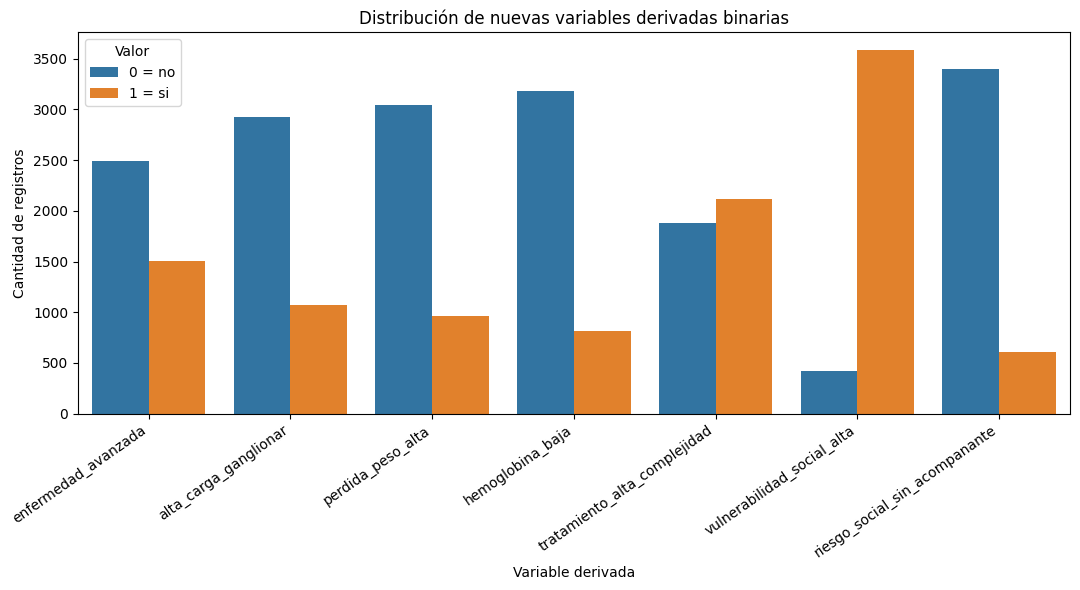

In [ ]:
variables_grafico_fe = [
    "enfermedad_avanzada",
    "alta_carga_ganglionar",
    "perdida_peso_alta",
    "hemoglobina_baja",
    "tratamiento_alta_complejidad",
    "vulnerabilidad_social_alta",
    "riesgo_social_sin_acompanante"
]

df_fe_plot = X_train_fe[variables_grafico_fe].melt(
    var_name="variable_derivada",
    value_name="valor"
)

df_fe_plot["valor"] = df_fe_plot["valor"].map({
    0: "0 = no",
    1: "1 = si"
})

plt.figure(figsize=(11, 6))

sns.countplot(
    data=df_fe_plot,
    x="variable_derivada",
    hue="valor"
)

plt.title("Distribución de nuevas variables derivadas binarias")
plt.xlabel("Variable derivada")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Valor")

plt.tight_layout()
plt.savefig("dp_08_variables_derivadas_binarias.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis DP-08: Creación de nuevas variables derivadas

En la etapa DP-08 se realizó la creación de **13 nuevas variables derivadas** a partir de la información clínica, nutricional, sintomática, terapéutica y social disponible en el dataset. Esta etapa corresponde al proceso de **Feature Engineering**, cuyo objetivo es construir variables que concentren información relevante y puedan mejorar el poder predictivo del modelo.

Antes de crear las nuevas variables, los conjuntos tenían **68 columnas**. Después de la transformación, tanto `X_train_fe` como `X_test_fe` quedaron con **81 columnas**, lo cual confirma que se agregaron correctamente las 13 nuevas características en ambos conjuntos.

Las nuevas variables creadas fueron:

| Tipo de variable derivada          | Variables creadas                                                          |
| ---------------------------------- | -------------------------------------------------------------------------- |
| Severidad clínica                  | `indice_avance_oncologico`, `enfermedad_avanzada`, `alta_carga_ganglionar` |
| Deterioro nutricional/hematológico | `perdida_peso_alta`, `hemoglobina_baja`, `indice_deterioro_nutricional`    |
| Carga sintomática                  | `dolor_alto`, `fatiga_alta`, `conteo_sintomas_relevantes`                  |
| Tratamiento                        | `conteo_necesidades_tratamiento`, `tratamiento_alta_complejidad`           |
| Contexto social                    | `vulnerabilidad_social_alta`, `riesgo_social_sin_acompanante`              |

Estas variables son relevantes porque resumen patrones que ya fueron identificados durante el EDA. Por ejemplo, el análisis exploratorio mostró que variables como `estadio`, `profundidad_tumor`, `metastasis`, `ganglios_afectados`, `perdida_peso_kg`, `hemoglobina`, `anemia`, `dolor`, `estado_funcional` y `requiere_quimioterapia` tenían una relación importante con `nivel_prioridad`. Por ello, las nuevas variables buscan combinar esa información en indicadores más interpretables para el modelo.

La variable `indice_avance_oncologico` resume el avance clínico del paciente combinando estadio, profundidad tumoral, metástasis y ganglios afectados. Esta variable puede ayudar al modelo a capturar de forma integrada la gravedad oncológica. Asimismo, `enfermedad_avanzada` identifica pacientes con criterios clínicos de mayor severidad, como estadio avanzado, presencia de metástasis o invasión local/diseminada.

En el componente nutricional, se crearon variables como `perdida_peso_alta`, `hemoglobina_baja` e `indice_deterioro_nutricional`, las cuales representan condiciones importantes en pacientes con cáncer gástrico. Estas variables permiten resumir el deterioro físico y nutricional del paciente.

También se generaron variables relacionadas con síntomas, como `conteo_sintomas_relevantes`, que suma la presencia de dolor alto, fatiga alta, vómitos frecuentes, sangrado digestivo, dificultad para alimentarse y anemia. Esta variable puede ser útil porque no solo considera un síntoma aislado, sino la acumulación de varios signos clínicos.

En cuanto al tratamiento, `conteo_necesidades_tratamiento` resume cuántas intervenciones requiere el paciente, mientras que `tratamiento_alta_complejidad` identifica casos que requieren quimioterapia o cuidados paliativos. Estas variables pueden aportar al modelo información sobre la complejidad del manejo clínico.

Finalmente, se incorporaron variables sociales como `vulnerabilidad_social_alta` y `riesgo_social_sin_acompanante`. Aunque en el EDA las variables sociales mostraron menor asociación con la prioridad clínica, se mantienen como variables complementarias porque representan el contexto de vulnerabilidad de los pacientes atendidos por ALDIMI.

La validación fue correcta, ya que no se generaron valores nulos en ninguna de las nuevas variables, ni en entrenamiento ni en prueba. Esto confirma que las reglas de creación fueron aplicadas correctamente.

# Conclusión DP-08

La creación de variables derivadas permitió enriquecer el dataset con indicadores clínicos, nutricionales, sintomáticos, terapéuticos y sociales más interpretables. Estas nuevas características resumen información relevante identificada en el EDA y pueden ayudar al modelo a capturar patrones de mayor severidad, deterioro físico, carga sintomática y complejidad de tratamiento. Al finalizar esta etapa, los conjuntos de entrenamiento y prueba quedaron con 81 variables y sin valores nulos en las nuevas características.

## DP-09: Escalamiento final después de Feature Engineering

In [ ]:
print("Dimensiones antes del escalamiento final:")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe:", X_test_fe.shape)

Dimensiones antes del escalamiento final:
X_train_fe: (3999, 81)
X_test_fe: (1001, 81)


In [ ]:
variables_a_escalar_final = [
    "dias_desde_diagnostico",
    "dias_en_albergue",
    "edad",
    "ganglios_afectados",
    "perdida_peso_kg",
    "hemoglobina",
    "indice_avance_oncologico",
    "indice_deterioro_nutricional",
    "conteo_sintomas_relevantes",
    "conteo_necesidades_tratamiento"
]

print("Variables que serán escaladas:")
print(variables_a_escalar_final)

Variables que serán escaladas:
['dias_desde_diagnostico', 'dias_en_albergue', 'edad', 'ganglios_afectados', 'perdida_peso_kg', 'hemoglobina', 'indice_avance_oncologico', 'indice_deterioro_nutricional', 'conteo_sintomas_relevantes', 'conteo_necesidades_tratamiento']


In [ ]:
print("Estadísticos antes del escalamiento final - TRAIN:")
display(X_train_fe[variables_a_escalar_final].describe().T)

print("\nEstadísticos antes del escalamiento final - TEST:")
display(X_test_fe[variables_a_escalar_final].describe().T)

Estadísticos antes del escalamiento final - TRAIN:


,count,mean,std,min,25%,50%,75%,max
dias_desde_diagnostico,3999.0,59.562891,26.890426,1.0,40.0,59.0,78.00,147.0
dias_en_albergue,3999.0,22.393098,16.695535,0.0,9.0,19.0,33.00,74.0
edad,3999.0,58.719180,18.391670,15.0,45.0,63.0,72.00,90.0
ganglios_afectados,3999.0,3.665166,4.267056,0.0,0.0,2.0,6.00,17.0
perdida_peso_kg,3999.0,5.795824,2.974362,0.0,3.7,5.8,7.85,16.6
hemoglobina,3999.0,11.898400,1.137196,7.9,11.1,11.9,12.70,15.5
indice_avance_oncologico,3999.0,8.247312,6.611161,0.0,3.0,6.0,13.00,28.0
indice_deterioro_nutricional,3999.0,2.210553,1.595290,0.0,1.0,2.0,3.00,5.0
conteo_sintomas_relevantes,3999.0,2.215304,1.418595,0.0,1.0,2.0,3.00,6.0
conteo_necesidades_tratamiento,3999.0,1.919730,0.874466,0.0,1.0,2.0,3.00,4.0



Estadísticos antes del escalamiento final - TEST:


,count,mean,std,min,25%,50%,75%,max
dias_desde_diagnostico,1001.0,59.912088,26.739526,4.0,40.0,61.0,78.0,144.0
dias_en_albergue,1001.0,21.799201,16.237877,0.0,8.0,19.0,32.0,74.0
edad,1001.0,57.943057,18.539627,15.0,45.0,62.0,71.0,90.0
ganglios_afectados,1001.0,3.379620,4.043729,0.0,0.0,2.0,5.0,17.0
perdida_peso_kg,1001.0,5.571229,2.898978,0.0,3.6,5.6,7.5,13.5
hemoglobina,1001.0,11.960140,1.126730,8.4,11.3,12.0,12.7,15.0
indice_avance_oncologico,1001.0,7.786214,6.344151,0.0,2.0,6.0,12.0,28.0
indice_deterioro_nutricional,1001.0,2.058941,1.589189,0.0,0.0,2.0,3.0,5.0
conteo_sintomas_relevantes,1001.0,2.107892,1.375626,0.0,1.0,2.0,3.0,6.0
conteo_necesidades_tratamiento,1001.0,1.855145,0.914328,0.0,1.0,2.0,2.0,4.0


In [ ]:

scaler_final = StandardScaler()

X_train_final = X_train_fe.copy()
X_test_final = X_test_fe.copy()

scaler_final.fit(X_train_final[variables_a_escalar_final])

X_train_final[variables_a_escalar_final] = scaler_final.transform(
    X_train_final[variables_a_escalar_final]
)

X_test_final[variables_a_escalar_final] = scaler_final.transform(
    X_test_final[variables_a_escalar_final]
)

print("Escalamiento final aplicado correctamente.")

Escalamiento final aplicado correctamente.


In [ ]:
print("Dimensiones finales:")
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

print("\nTotal de nulos en X_train_final:")
print(X_train_final.isnull().sum().sum())

print("\nTotal de nulos en X_test_final:")
print(X_test_final.isnull().sum().sum())

print("\nColumnas tipo object/category en X_train_final:")
print(X_train_final.select_dtypes(include=["object", "category"]).columns.tolist())

print("\nColumnas tipo object/category en X_test_final:")
print(X_test_final.select_dtypes(include=["object", "category"]).columns.tolist())

Dimensiones finales:
X_train_final: (3999, 81)
X_test_final: (1001, 81)

Total de nulos en X_train_final:
0

Total de nulos en X_test_final:
0

Columnas tipo object/category en X_train_final:
[]

Columnas tipo object/category en X_test_final:
[]


In [ ]:
df_parametros_scaler_final = pd.DataFrame({
    "variable": variables_a_escalar_final,
    "media_train_usada": scaler_final.mean_,
    "desviacion_train_usada": scaler_final.scale_
})

display(df_parametros_scaler_final)

,variable,media_train_usada,desviacion_train_usada
0,dias_desde_diagnostico,59.562891,26.887064
1,dias_en_albergue,22.393098,16.693447
2,edad,58.719180,18.389371
3,ganglios_afectados,3.665166,4.266523
4,perdida_peso_kg,5.795824,2.973990
5,hemoglobina,11.898400,1.137054
6,indice_avance_oncologico,8.247312,6.610335
7,indice_deterioro_nutricional,2.210553,1.595091
8,conteo_sintomas_relevantes,2.215304,1.418418
9,conteo_necesidades_tratamiento,1.919730,0.874357


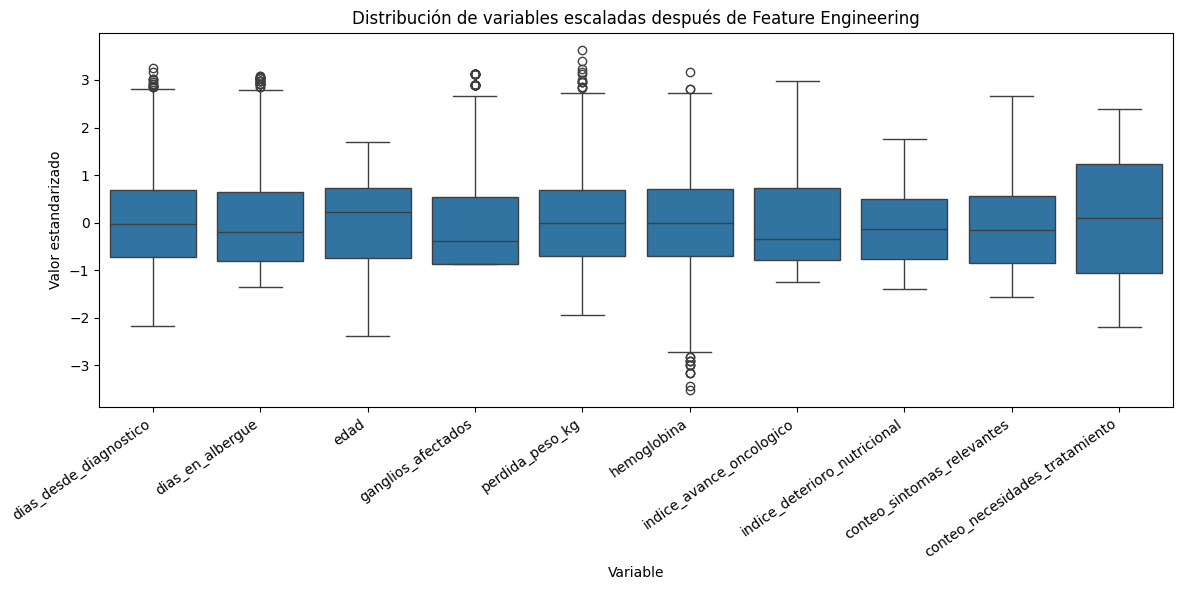

In [ ]:
df_final_scaled_plot = X_train_final[variables_a_escalar_final].melt(
    var_name="variable",
    value_name="valor_estandarizado"
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_final_scaled_plot,
    x="variable",
    y="valor_estandarizado"
)

plt.title("Distribución de variables escaladas después de Feature Engineering")
plt.xlabel("Variable")
plt.ylabel("Valor estandarizado")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.savefig("dp_09_variables_escaladas_final.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis DP-09: Escalamiento final después del Feature Engineering

En la etapa DP-09 se realizó el **escalamiento final** después de crear las nuevas variables derivadas. Esta decisión fue necesaria porque en la DP-08 se agregaron variables numéricas nuevas, como `indice_avance_oncologico`, `indice_deterioro_nutricional`, `conteo_sintomas_relevantes` y `conteo_necesidades_tratamiento`, las cuales también tienen escalas propias y debían ser estandarizadas junto con las variables numéricas originales.

Antes del escalamiento final, los conjuntos `X_train_fe` y `X_test_fe` tenían **81 variables**. Después del proceso, los conjuntos finales `X_train_final` y `X_test_final` mantuvieron las mismas dimensiones: **3999 registros y 81 variables** para entrenamiento, y **1001 registros y 81 variables** para prueba. Esto confirma que el escalamiento no eliminó ni agregó columnas, sino que únicamente transformó la escala de las variables numéricas seleccionadas.

Las variables escaladas fueron las seis numéricas originales: `dias_desde_diagnostico`, `dias_en_albergue`, `edad`, `ganglios_afectados`, `perdida_peso_kg` y `hemoglobina`; además de cuatro variables derivadas: `indice_avance_oncologico`, `indice_deterioro_nutricional`, `conteo_sintomas_relevantes` y `conteo_necesidades_tratamiento`.

El escalador fue ajustado únicamente con los datos de entrenamiento. Esto es correcto porque evita fuga de información desde el conjunto de prueba. Los parámetros usados reflejan las medias y desviaciones estándar del entrenamiento, por ejemplo: `indice_avance_oncologico` tuvo una media de **8.25** y desviación estándar de **6.61**, mientras que `conteo_sintomas_relevantes` tuvo una media de **2.22** y desviación estándar de **1.42**.

Después del escalamiento, se verificó que ambos conjuntos quedaran sin valores nulos y sin columnas tipo `object` o `category`. Esto confirma que el dataset ya se encuentra completamente numérico, limpio y listo para ser utilizado por modelos de Machine Learning.

El gráfico generado muestra la distribución de las variables escaladas después del Feature Engineering. En él se observa que las variables quedaron en una escala comparable, centradas alrededor de valores cercanos a 0, aunque algunas conservan valores extremos esperados por la presencia de casos clínicos más severos.

# Conclusión DP-09

El escalamiento final permitió estandarizar tanto las variables numéricas originales como las nuevas variables derivadas creadas durante el Feature Engineering. Al finalizar esta etapa, los conjuntos `X_train_final` y `X_test_final` quedaron completamente numéricos, sin valores nulos, con la misma estructura de columnas y listos para continuar con la revisión del desbalance de clases y la preparación final para el modelado.


## DP-10: Revisión de desbalance de clases y estrategia de balanceo

In [ ]:
print("Distribución de clases en y_train:")
display(y_train.value_counts())

print("\nDistribución porcentual en y_train:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución de clases en y_test:")
display(y_test.value_counts())

print("\nDistribución porcentual en y_test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Distribución de clases en y_train:


,count
nivel_prioridad,
medio,1427
alto,1383
bajo,1189



Distribución porcentual en y_train:


,proportion
nivel_prioridad,
medio,35.68
alto,34.58
bajo,29.73



Distribución de clases en y_test:


,count
nivel_prioridad,
medio,363
bajo,331
alto,307



Distribución porcentual en y_test:


,proportion
nivel_prioridad,
medio,36.26
bajo,33.07
alto,30.67


In [ ]:
conteo_train = y_train.value_counts()

clase_mayoritaria = conteo_train.idxmax()
clase_minoritaria = conteo_train.idxmin()

cantidad_mayoritaria = conteo_train.max()
cantidad_minoritaria = conteo_train.min()

ratio_desbalance = cantidad_mayoritaria / cantidad_minoritaria

print("Clase mayoritaria:", clase_mayoritaria, "-", cantidad_mayoritaria)
print("Clase minoritaria:", clase_minoritaria, "-", cantidad_minoritaria)
print("Ratio de desbalance:", round(ratio_desbalance, 3))

Clase mayoritaria: medio - 1427
Clase minoritaria: bajo - 1189
Ratio de desbalance: 1.2


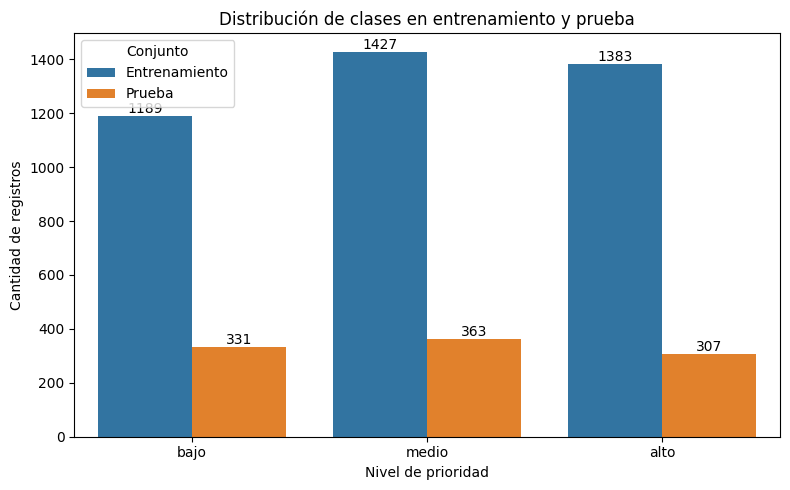

In [ ]:
df_clases_train = y_train.value_counts().reset_index()
df_clases_train.columns = ["nivel_prioridad", "cantidad"]
df_clases_train["conjunto"] = "Entrenamiento"

df_clases_test = y_test.value_counts().reset_index()
df_clases_test.columns = ["nivel_prioridad", "cantidad"]
df_clases_test["conjunto"] = "Prueba"

df_clases = pd.concat([df_clases_train, df_clases_test], ignore_index=True)

orden_prioridad = ["bajo", "medio", "alto"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_clases,
    x="nivel_prioridad",
    y="cantidad",
    hue="conjunto",
    order=orden_prioridad
)

plt.title("Distribución de clases en entrenamiento y prueba")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Cantidad de registros")
plt.legend(title="Conjunto")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig("dp_10_distribucion_clases_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
if ratio_desbalance < 1.5:
    decision_balanceo = "No se recomienda aplicar SMOTE inicialmente, porque el desbalance es bajo."
elif ratio_desbalance < 2.0:
    decision_balanceo = "El desbalance es moderado. Se puede comparar un modelo sin SMOTE vs con class_weight."
else:
    decision_balanceo = "El desbalance es alto. Se recomienda evaluar técnicas como SMOTE en entrenamiento."

print(decision_balanceo)

No se recomienda aplicar SMOTE inicialmente, porque el desbalance es bajo.


# Análisis DP-10: Revisión de desbalance de clases

En la etapa DP-10 se revisó la distribución de la variable objetivo `nivel_prioridad` en los conjuntos de entrenamiento y prueba, con el objetivo de decidir si era necesario aplicar una técnica de balanceo como SMOTE.

En el conjunto de entrenamiento, la clase con mayor cantidad de registros fue `medio`, con **1427 casos**, seguida de `alto`, con **1383 casos**, y `bajo`, con **1189 casos**. En términos porcentuales, la distribución fue **35.68% medio**, **34.58% alto** y **29.73% bajo**. Esto indica que las tres clases se encuentran relativamente equilibradas.

En el conjunto de prueba también se mantuvo una distribución razonable: `medio` representa **36.26%**, `bajo` **33.07%** y `alto` **30.67%**. Aunque las proporciones no son exactamente iguales a las del entrenamiento, las tres clases siguen estando presentes de manera balanceada.

El ratio de desbalance calculado fue **1.2**, obtenido al comparar la clase mayoritaria (`medio`, 1427 registros) con la clase minoritaria (`bajo`, 1189 registros). Este valor es bajo, ya que la diferencia entre clases no es grande.

Por esa razón, **no se recomienda aplicar SMOTE inicialmente**. Aplicar SMOTE cuando el desbalance es leve podría generar datos sintéticos innecesarios y alterar la distribución natural del problema. En este caso, es más adecuado entrenar primero los modelos con la distribución original y evaluar su desempeño usando métricas como **accuracy**, **macro-F1**, **recall por clase** y **matriz de confusión**.

# Conclusión DP-10

La revisión del balance de clases muestra que `nivel_prioridad` no presenta un desbalance severo. Las clases `bajo`, `medio` y `alto` mantienen proporciones cercanas tanto en entrenamiento como en prueba, y el ratio de desbalance es de solo **1.2**. Por ello, no se aplicará SMOTE en esta etapa inicial. La estrategia recomendada es entrenar primero los modelos con los datos originales y, si durante el modelado se observa bajo rendimiento en alguna clase, comparar posteriormente con técnicas como `class_weight` o SMOTE aplicado únicamente al conjunto de entrenamiento.


## DP-11: Selección de características

In [ ]:
print("Dimensiones de X_train_final:")
print(X_train_final.shape)

print("\nDimensiones de X_test_final:")
print(X_test_final.shape)

print("\nDistribución de y_train:")
display(y_train.value_counts())

Dimensiones de X_train_final:
(3999, 81)

Dimensiones de X_test_final:
(1001, 81)

Distribución de y_train:


,count
nivel_prioridad,
medio,1427
alto,1383
bajo,1189


In [ ]:
y_train_alto = (y_train == "alto").astype(int)

print("Distribución de variable auxiliar alto/no alto:")
display(y_train_alto.value_counts())

print("\nPorcentaje:")
display((y_train_alto.value_counts(normalize=True) * 100).round(2))

Distribución de variable auxiliar alto/no alto:


,count
nivel_prioridad,
0,2616
1,1383



Porcentaje:


,proportion
nivel_prioridad,
0,65.42
1,34.58


## A. Selección de características para Regresión Logística

In [ ]:
# ==============================
# A1. REGRESIÓN LOGÍSTICA MULTICLASE
# ==============================

pesos_clase_multiclase = {
    "bajo": 1.0,
    "medio": 1.0,
    "alto": 2.0
}

lr_multiclase_selector = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=5000,
    class_weight=pesos_clase_multiclase,
    random_state=42
)

lr_multiclase_selector.fit(X_train_final, y_train)

print("Clases del modelo multiclase:")
print(lr_multiclase_selector.classes_)

Clases del modelo multiclase:
['alto' 'bajo' 'medio']


In [ ]:
# ==============================
# A2. REGRESIÓN LOGÍSTICA BINARIA ENFOCADA EN CLASE ALTA
# ==============================

lr_alto_selector = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=5000,
    class_weight={0: 1.0, 1: 2.0},
    random_state=42
)

lr_alto_selector.fit(X_train_final, y_train_alto)

LogisticRegression(class_weight={0: 1.0, 1: 2.0}, max_iter=5000,
                   random_state=42)

In [ ]:
# ==============================
# A3. RANKING DE VARIABLES PARA REGRESIÓN LOGÍSTICA
# ==============================

variables_modelo = X_train_final.columns.tolist()

# Coeficientes globales multiclase
coef_multiclase_abs = np.abs(lr_multiclase_selector.coef_)
coef_global_lr = coef_multiclase_abs.max(axis=0)

# Coeficiente específico para clase alto dentro del modelo multiclase
indice_clase_alto = list(lr_multiclase_selector.classes_).index("alto")
coef_alto_multiclase = coef_multiclase_abs[indice_clase_alto]

# Coeficientes del modelo binario alto/no alto
coef_alto_binario = np.abs(lr_alto_selector.coef_[0])

df_features_lr = pd.DataFrame({
    "variable": variables_modelo,
    "coef_global_multiclase": coef_global_lr,
    "coef_alto_multiclase": coef_alto_multiclase,
    "coef_alto_binario": coef_alto_binario
})

# Normalización de puntajes para combinarlos
def normalizar_serie(s):
    if s.max() == 0:
        return s
    return s / s.max()

df_features_lr["coef_global_norm"] = normalizar_serie(df_features_lr["coef_global_multiclase"])
df_features_lr["coef_alto_multiclase_norm"] = normalizar_serie(df_features_lr["coef_alto_multiclase"])
df_features_lr["coef_alto_binario_norm"] = normalizar_serie(df_features_lr["coef_alto_binario"])

# Puntaje final orientado a detección de prioridad alta
df_features_lr["puntaje_lr"] = (
    0.40 * df_features_lr["coef_global_norm"] +
    0.30 * df_features_lr["coef_alto_multiclase_norm"] +
    0.30 * df_features_lr["coef_alto_binario_norm"]
)

df_features_lr = df_features_lr.sort_values(
    by="puntaje_lr",
    ascending=False
)

display(df_features_lr.head(30))

,variable,coef_global_multiclase,coef_alto_multiclase,coef_alto_binario,coef_global_norm,coef_alto_multiclase_norm,coef_alto_binario_norm,puntaje_lr
69,enfermedad_avanzada,2.716271,2.716271,4.066499,0.933284,1.000000,1.000000,0.973314
25,requiere_quimioterapia,1.792448,1.792448,2.815430,0.615868,0.659893,0.692347,0.652019
64,tratamiento_principal_cuidados_paliativos,2.910443,1.532537,0.262167,1.000000,0.564206,0.064470,0.588603
27,requiere_cuidados_paliativos,2.910443,1.532537,0.262167,1.000000,0.564206,0.064470,0.588603
62,tratamiento_principal_cirugia,1.287414,1.287414,2.038245,0.442343,0.473964,0.501229,0.469495
78,tratamiento_alta_complejidad,1.373237,1.365354,1.665030,0.471831,0.502658,0.409450,0.462365
8,estadio,2.701190,0.568523,0.268785,0.928103,0.209303,0.066097,0.453861
59,sitio_metastasis_ninguno,1.244844,1.244844,1.912561,0.427716,0.458291,0.470321,0.449670
12,metastasis,1.175583,1.171496,1.471906,0.403919,0.431288,0.361959,0.399542
24,requiere_cirugia,1.039481,0.723734,1.803067,0.357156,0.266444,0.443396,0.355814


In [ ]:
# ==============================
# A4. SELECCIÓN DE VARIABLES PARA REGRESIÓN LOGÍSTICA
# ==============================

top_n_lr = 30

variables_lr_seleccionadas = df_features_lr.head(top_n_lr)["variable"].tolist()

X_train_lr_selected = X_train_final[variables_lr_seleccionadas].copy()
X_test_lr_selected = X_test_final[variables_lr_seleccionadas].copy()

print("Cantidad de variables seleccionadas para Regresión Logística:")
print(len(variables_lr_seleccionadas))

print("\nDimensiones de X_train_lr_selected:")
print(X_train_lr_selected.shape)

print("\nDimensiones de X_test_lr_selected:")
print(X_test_lr_selected.shape)

print("\nVariables seleccionadas para Regresión Logística:")
for col in variables_lr_seleccionadas:
    print("-", col)

Cantidad de variables seleccionadas para Regresión Logística:
30

Dimensiones de X_train_lr_selected:
(3999, 30)

Dimensiones de X_test_lr_selected:
(1001, 30)

Variables seleccionadas para Regresión Logística:
- enfermedad_avanzada
- requiere_quimioterapia
- tratamiento_principal_cuidados_paliativos
- requiere_cuidados_paliativos
- tratamiento_principal_cirugia
- tratamiento_alta_complejidad
- estadio
- sitio_metastasis_ninguno
- metastasis
- requiere_cirugia
- tratamiento_principal_quimioterapia
- indice_avance_oncologico
- tratamiento_principal_cirugia_quimioterapia
- acompanante
- fatiga_alta
- dolor
- conteo_sintomas_relevantes
- estado_funcional
- estado_nutricional
- tratamiento_principal_seguimiento
- grado_histologico
- requiere_soporte_nutricional
- sangrado_digestivo
- tratamiento_principal_soporte_nutricional
- ganglios_afectados
- region_procedencia_Loreto
- vomitos_frecuentes
- indice_deterioro_nutricional
- sitio_metastasis_higado
- nivel_vulnerabilidad


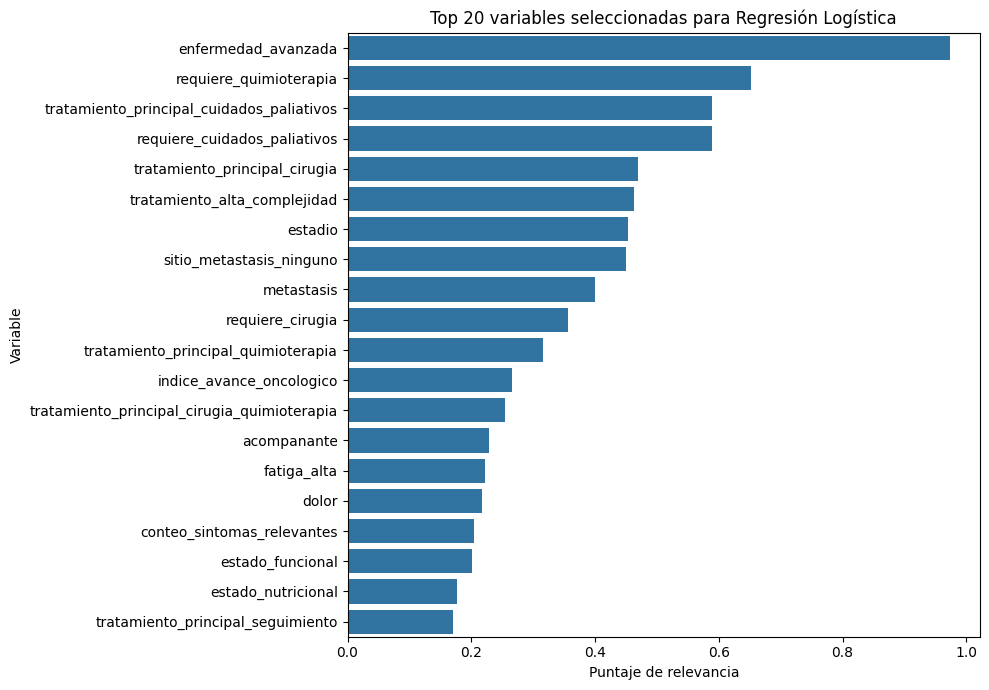

In [ ]:
# ==============================
# A5. GRÁFICO TOP 20 REGRESIÓN LOGÍSTICA
# ==============================

top20_lr = df_features_lr.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top20_lr,
    x="puntaje_lr",
    y="variable"
)

plt.title("Top 20 variables seleccionadas para Regresión Logística")
plt.xlabel("Puntaje de relevancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.savefig("dp_11_top20_variables_regresion_logistica.png", dpi=300, bbox_inches="tight")
plt.show()

## B. Selección de características para Random Forest

In [ ]:
# ==============================
# B1. RANDOM FOREST MULTICLASE
# ==============================

rf_multiclase_selector = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight=pesos_clase_multiclase,
    n_jobs=-1
)

rf_multiclase_selector.fit(X_train_final, y_train)

RandomForestClassifier(class_weight={'alto': 2.0, 'bajo': 1.0, 'medio': 1.0},
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# ==============================
# B2. RANDOM FOREST BINARIO ENFOCADO EN CLASE ALTA
# ==============================

rf_alto_selector = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight={0: 1.0, 1: 2.0},
    n_jobs=-1
)

rf_alto_selector.fit(X_train_final, y_train_alto)

RandomForestClassifier(class_weight={0: 1.0, 1: 2.0}, n_estimators=500,
                       n_jobs=-1, random_state=42)

In [ ]:
# ==============================
# B3. RANKING DE VARIABLES PARA RANDOM FOREST
# ==============================

df_features_rf = pd.DataFrame({
    "variable": variables_modelo,
    "importancia_global_multiclase": rf_multiclase_selector.feature_importances_,
    "importancia_alto_binario": rf_alto_selector.feature_importances_
})

df_features_rf["importancia_global_norm"] = normalizar_serie(
    df_features_rf["importancia_global_multiclase"]
)

df_features_rf["importancia_alto_norm"] = normalizar_serie(
    df_features_rf["importancia_alto_binario"]
)

# Puntaje final orientado a desempeño general + detección de prioridad alta
df_features_rf["puntaje_rf"] = (
    0.40 * df_features_rf["importancia_global_norm"] +
    0.60 * df_features_rf["importancia_alto_norm"]
)

df_features_rf = df_features_rf.sort_values(
    by="puntaje_rf",
    ascending=False
)

display(df_features_rf.head(30))

,variable,importancia_global_multiclase,importancia_alto_binario,importancia_global_norm,importancia_alto_norm,puntaje_rf
8,estadio,0.178308,0.175765,1.000000,1.000000,1.000000
68,indice_avance_oncologico,0.133996,0.126406,0.751484,0.719179,0.732101
69,enfermedad_avanzada,0.097145,0.142324,0.544816,0.809740,0.703771
11,ganglios_afectados,0.066152,0.071144,0.371001,0.404771,0.391263
10,profundidad_tumor,0.059087,0.058016,0.331377,0.330080,0.330599
70,alta_carga_ganglionar,0.034352,0.048617,0.192653,0.276601,0.243022
13,perdida_peso_kg,0.036606,0.037349,0.205299,0.212496,0.209617
23,estado_funcional,0.030651,0.028370,0.171898,0.161407,0.165603
73,indice_deterioro_nutricional,0.015824,0.022417,0.088744,0.127540,0.112022
76,conteo_sintomas_relevantes,0.023327,0.016831,0.130822,0.095756,0.109782


In [ ]:
# ==============================
# B4. SELECCIÓN DE VARIABLES PARA RANDOM FOREST
# ==============================

top_n_rf = 30

variables_rf_seleccionadas = df_features_rf.head(top_n_rf)["variable"].tolist()

X_train_rf_selected = X_train_final[variables_rf_seleccionadas].copy()
X_test_rf_selected = X_test_final[variables_rf_seleccionadas].copy()

print("Cantidad de variables seleccionadas para Random Forest:")
print(len(variables_rf_seleccionadas))

print("\nDimensiones de X_train_rf_selected:")
print(X_train_rf_selected.shape)

print("\nDimensiones de X_test_rf_selected:")
print(X_test_rf_selected.shape)

print("\nVariables seleccionadas para Random Forest:")
for col in variables_rf_seleccionadas:
    print("-", col)

Cantidad de variables seleccionadas para Random Forest:
30

Dimensiones de X_train_rf_selected:
(3999, 30)

Dimensiones de X_test_rf_selected:
(1001, 30)

Variables seleccionadas para Random Forest:
- estadio
- indice_avance_oncologico
- enfermedad_avanzada
- ganglios_afectados
- profundidad_tumor
- alta_carga_ganglionar
- perdida_peso_kg
- estado_funcional
- indice_deterioro_nutricional
- conteo_sintomas_relevantes
- tratamiento_alta_complejidad
- tratamiento_principal_cuidados_paliativos
- requiere_cuidados_paliativos
- dolor
- hemoglobina
- tratamiento_principal_cirugia
- grado_histologico
- dias_desde_diagnostico
- dias_en_albergue
- edad
- perdida_peso_alta
- estado_nutricional
- conteo_necesidades_tratamiento
- sitio_metastasis_ninguno
- requiere_quimioterapia
- anemia
- metastasis
- requiere_cirugia
- requiere_soporte_nutricional
- dolor_alto


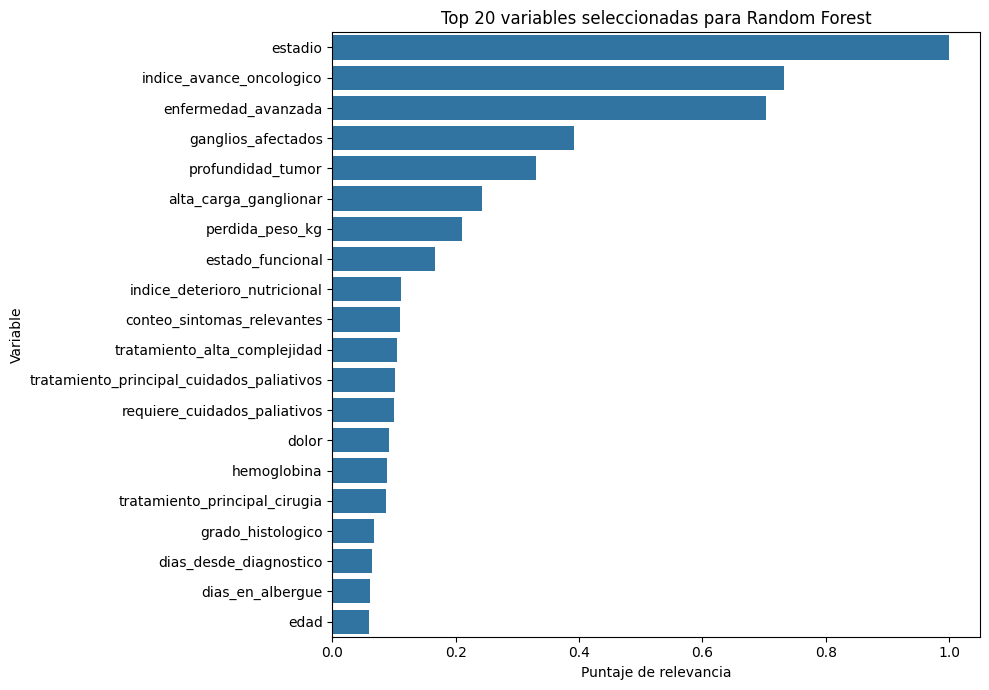

In [ ]:
# ==============================
# B5. GRÁFICO TOP 20 RANDOM FOREST
# ==============================

top20_rf = df_features_rf.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top20_rf,
    x="puntaje_rf",
    y="variable"
)

plt.title("Top 20 variables seleccionadas para Random Forest")
plt.xlabel("Puntaje de relevancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.savefig("dp_11_top20_variables_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

## C. Comparación de variables seleccionadas por ambos modelos

In [ ]:
# ==============================
# COMPARACIÓN ENTRE VARIABLES SELECCIONADAS
# ==============================

set_lr = set(variables_lr_seleccionadas)
set_rf = set(variables_rf_seleccionadas)

variables_comunes = sorted(list(set_lr.intersection(set_rf)))
variables_solo_lr = sorted(list(set_lr - set_rf))
variables_solo_rf = sorted(list(set_rf - set_lr))

print("Variables comunes entre ambos modelos:", len(variables_comunes))
print(variables_comunes)

print("\nVariables solo seleccionadas para Regresión Logística:", len(variables_solo_lr))
print(variables_solo_lr)

print("\nVariables solo seleccionadas para Random Forest:", len(variables_solo_rf))
print(variables_solo_rf)

Variables comunes entre ambos modelos: 19
['conteo_sintomas_relevantes', 'dolor', 'enfermedad_avanzada', 'estadio', 'estado_funcional', 'estado_nutricional', 'ganglios_afectados', 'grado_histologico', 'indice_avance_oncologico', 'indice_deterioro_nutricional', 'metastasis', 'requiere_cirugia', 'requiere_cuidados_paliativos', 'requiere_quimioterapia', 'requiere_soporte_nutricional', 'sitio_metastasis_ninguno', 'tratamiento_alta_complejidad', 'tratamiento_principal_cirugia', 'tratamiento_principal_cuidados_paliativos']

Variables solo seleccionadas para Regresión Logística: 11
['acompanante', 'fatiga_alta', 'nivel_vulnerabilidad', 'region_procedencia_Loreto', 'sangrado_digestivo', 'sitio_metastasis_higado', 'tratamiento_principal_cirugia_quimioterapia', 'tratamiento_principal_quimioterapia', 'tratamiento_principal_seguimiento', 'tratamiento_principal_soporte_nutricional', 'vomitos_frecuentes']

Variables solo seleccionadas para Random Forest: 11
['alta_carga_ganglionar', 'anemia', 'conte

In [ ]:
# ==============================
# TABLA RESUMEN DE SELECCIÓN
# ==============================

df_comparacion_seleccion = pd.DataFrame({
    "grupo": [
        "Comunes en ambos modelos",
        "Solo Regresión Logística",
        "Solo Random Forest"
    ],
    "cantidad_variables": [
        len(variables_comunes),
        len(variables_solo_lr),
        len(variables_solo_rf)
    ]
})

display(df_comparacion_seleccion)

,grupo,cantidad_variables
0,Comunes en ambos modelos,19
1,Solo Regresión Logística,11
2,Solo Random Forest,11


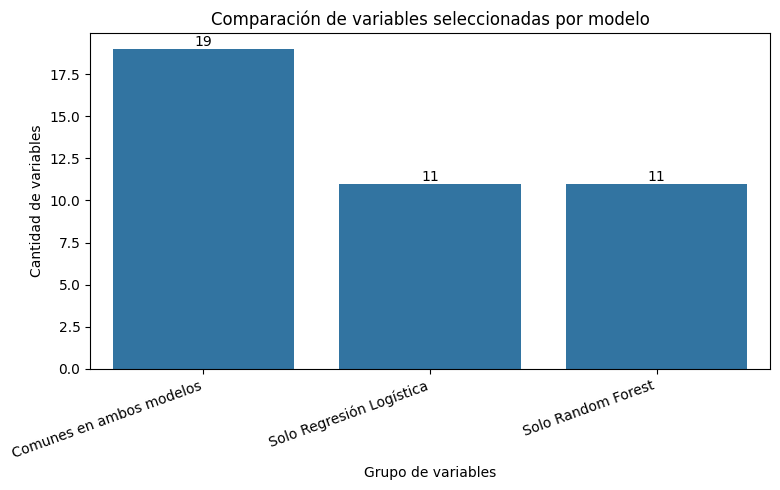

In [ ]:
# ==============================
# GRÁFICO COMPARATIVO DE SELECCIÓN
# ==============================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_comparacion_seleccion,
    x="grupo",
    y="cantidad_variables"
)

plt.title("Comparación de variables seleccionadas por modelo")
plt.xlabel("Grupo de variables")
plt.ylabel("Cantidad de variables")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig("dp_11_comparacion_variables_seleccionadas.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis DP-11: Selección de características orientada a los modelos candidatos

En la etapa DP-11 se realizó una selección de características considerando los dos modelos candidatos definidos para el problema: **Regresión Logística Multinomial** y **Random Forest**. Esta decisión es importante porque ambos modelos aprenden de manera diferente. La Regresión Logística trabaja mejor con relaciones más directas e interpretables entre variables y clases, mientras que Random Forest puede capturar relaciones no lineales, umbrales e interacciones entre variables.

Además, la selección se orientó al objetivo principal del proyecto: **detectar correctamente a los pacientes de prioridad alta**. Por ello, se creó una variable auxiliar `alto/no alto`, donde los pacientes de prioridad alta fueron codificados como `1` y los demás como `0`. Esta variable no reemplaza a `nivel_prioridad`, sino que se utilizó únicamente para orientar la selección hacia las variables que ayudan a identificar mejor los casos críticos.

En el conjunto de entrenamiento, la clase `alto` representa el **34.58%** de los registros, mientras que las clases `bajo` y `medio` juntas representan el **65.42%**. Por esta razón, el análisis de características no se centró únicamente en la clasificación general, sino también en la capacidad de distinguir pacientes de prioridad alta frente al resto.

## Selección para Regresión Logística

Para Regresión Logística se seleccionaron **30 variables**. Las más relevantes fueron `enfermedad_avanzada`, `requiere_quimioterapia`, `tratamiento_principal_cuidados_paliativos`, `requiere_cuidados_paliativos`, `tratamiento_principal_cirugia`, `tratamiento_alta_complejidad`, `estadio`, `sitio_metastasis_ninguno`, `metastasis` y `requiere_cirugia`.

Estas variables tienen sentido para Regresión Logística porque permiten separar de forma más directa las clases de prioridad. Por ejemplo, `enfermedad_avanzada`, `estadio`, `metastasis` y `requiere_quimioterapia` tienen una relación clínica clara con el aumento de prioridad. Asimismo, las variables derivadas del tratamiento principal ayudan al modelo lineal a diferenciar perfiles clínicos específicos, como pacientes en cirugía, quimioterapia, seguimiento o cuidados paliativos.

En este modelo aparecen varias variables tipo One-Hot de tratamiento, como `tratamiento_principal_cuidados_paliativos`, `tratamiento_principal_cirugia`, `tratamiento_principal_quimioterapia`, `tratamiento_principal_cirugia_quimioterapia` y `tratamiento_principal_seguimiento`. Esto ocurre porque la Regresión Logística interpreta cada categoría como un contraste directo frente a las demás, por lo que algunas categorías específicas pueden tener mucho peso para separar prioridades.

## Selección para Random Forest

Para Random Forest también se seleccionaron **30 variables**, pero el orden de importancia fue diferente. Las principales fueron `estadio`, `indice_avance_oncologico`, `enfermedad_avanzada`, `ganglios_afectados`, `profundidad_tumor`, `alta_carga_ganglionar`, `perdida_peso_kg`, `estado_funcional`, `indice_deterioro_nutricional` y `conteo_sintomas_relevantes`.

Este resultado es coherente con el funcionamiento de Random Forest, porque este modelo suele aprovechar mejor variables numéricas, umbrales e interacciones. Por ejemplo, puede separar mejor los casos usando reglas como mayor cantidad de ganglios afectados, mayor profundidad tumoral, mayor pérdida de peso o mayor índice de avance oncológico. Por eso, en Random Forest aparecen con mayor fuerza variables como `ganglios_afectados`, `profundidad_tumor`, `perdida_peso_kg`, `hemoglobina`, `edad`, `dias_desde_diagnostico` y `dias_en_albergue`.

A diferencia de la Regresión Logística, Random Forest no depende tanto de una relación lineal directa. Por ello, puede encontrar utilidad en variables que funcionan mejor mediante cortes o combinaciones, como `alta_carga_ganglionar`, `perdida_peso_alta`, `dolor_alto`, `conteo_necesidades_tratamiento` y `indice_deterioro_nutricional`.

## Variables comunes entre ambos modelos

Se identificaron **19 variables comunes** entre ambos modelos. Estas variables son especialmente importantes porque fueron consideradas relevantes tanto por un modelo lineal como por un modelo basado en árboles. Entre ellas se encuentran:

`enfermedad_avanzada`, `estadio`, `estado_funcional`, `estado_nutricional`, `ganglios_afectados`, `grado_histologico`, `indice_avance_oncologico`, `indice_deterioro_nutricional`, `metastasis`, `dolor`, `conteo_sintomas_relevantes`, `requiere_quimioterapia`, `requiere_cuidados_paliativos`, `requiere_cirugia`, `requiere_soporte_nutricional`, `tratamiento_alta_complejidad` y variables asociadas al tratamiento principal.

Estas variables son comunes porque representan los factores centrales del problema: avance oncológico, deterioro clínico, síntomas, estado funcional y complejidad del tratamiento. Es decir, son variables que tienen relación fuerte con la prioridad del paciente independientemente del tipo de modelo utilizado.

## Variables seleccionadas solo por Regresión Logística

Las variables seleccionadas solo por Regresión Logística fueron principalmente variables categóricas específicas o indicadores de tratamiento y contexto, como `acompanante`, `fatiga_alta`, `nivel_vulnerabilidad`, `region_procedencia_Loreto`, `sangrado_digestivo`, `sitio_metastasis_higado`, `vomitos_frecuentes` y varias categorías de `tratamiento_principal`.

Esto ocurre porque la Regresión Logística trabaja con pesos directos para cada variable. Por lo tanto, algunas categorías específicas pueden ayudar a mover la predicción hacia una clase determinada, aunque no sean tan importantes para un modelo de árboles. En este caso, las variables propias de Regresión Logística parecen aportar señales puntuales e interpretables para diferenciar ciertos perfiles de pacientes.

## Variables seleccionadas solo por Random Forest

Las variables seleccionadas solo por Random Forest fueron `alta_carga_ganglionar`, `anemia`, `conteo_necesidades_tratamiento`, `dias_desde_diagnostico`, `dias_en_albergue`, `dolor_alto`, `edad`, `hemoglobina`, `perdida_peso_alta`, `perdida_peso_kg` y `profundidad_tumor`.

Estas variables aparecen solo en Random Forest porque este modelo puede aprovechar mejor relaciones no lineales y puntos de corte. Por ejemplo, la pérdida de peso puede no tener una relación perfectamente lineal con la prioridad, pero sí puede ser muy útil cuando supera cierto umbral. Lo mismo ocurre con ganglios afectados, hemoglobina, profundidad tumoral o edad. Random Forest puede combinar estas variables con otras para formar reglas de decisión más flexibles.

# Conclusión DP-11

La selección de características permitió construir dos conjuntos de variables adaptados a los modelos candidatos. Regresión Logística priorizó variables con efecto directo e interpretable, especialmente relacionadas con enfermedad avanzada, tratamiento y categorías específicas. Random Forest priorizó variables clínicas continuas, índices derivados y variables que permiten reglas no lineales. La existencia de 19 variables comunes confirma que el avance oncológico, el estado funcional, los síntomas y la complejidad del tratamiento son factores centrales para predecir el nivel de prioridad. Por ello, se continuará al modelado comparando ambos enfoques, priorizando el **recall de la clase alta** como métrica principal.


## DP-12: Consolidación final de datasets para modelado

In [ ]:
# Dataset base completo preparado
dataset_base_modelado = {
    "X_train_final": X_train_final,
    "X_test_final": X_test_final,
    "y_train": y_train,
    "y_test": y_test
}

# Dataset específico para Regresión Logística
dataset_logistica = {
    "X_train": X_train_lr_selected,
    "X_test": X_test_lr_selected,
    "y_train": y_train,
    "y_test": y_test
}

# Dataset específico para Random Forest
dataset_random_forest = {
    "X_train": X_train_rf_selected,
    "X_test": X_test_rf_selected,
    "y_train": y_train,
    "y_test": y_test
}

print("Dataset base preparado:")
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDataset para Regresión Logística:")
print("X_train_lr_selected:", X_train_lr_selected.shape)
print("X_test_lr_selected:", X_test_lr_selected.shape)

print("\nDataset para Random Forest:")
print("X_train_rf_selected:", X_train_rf_selected.shape)
print("X_test_rf_selected:", X_test_rf_selected.shape)

Dataset base preparado:
X_train_final: (3999, 81)
X_test_final: (1001, 81)
y_train: (3999,)
y_test: (1001,)

Dataset para Regresión Logística:
X_train_lr_selected: (3999, 30)
X_test_lr_selected: (1001, 30)

Dataset para Random Forest:
X_train_rf_selected: (3999, 30)
X_test_rf_selected: (1001, 30)


In [ ]:
validacion_final = pd.DataFrame({
    "dataset": [
        "X_train_final",
        "X_test_final",
        "X_train_lr_selected",
        "X_test_lr_selected",
        "X_train_rf_selected",
        "X_test_rf_selected"
    ],
    "filas": [
        X_train_final.shape[0],
        X_test_final.shape[0],
        X_train_lr_selected.shape[0],
        X_test_lr_selected.shape[0],
        X_train_rf_selected.shape[0],
        X_test_rf_selected.shape[0]
    ],
    "columnas": [
        X_train_final.shape[1],
        X_test_final.shape[1],
        X_train_lr_selected.shape[1],
        X_test_lr_selected.shape[1],
        X_train_rf_selected.shape[1],
        X_test_rf_selected.shape[1]
    ],
    "nulos": [
        X_train_final.isnull().sum().sum(),
        X_test_final.isnull().sum().sum(),
        X_train_lr_selected.isnull().sum().sum(),
        X_test_lr_selected.isnull().sum().sum(),
        X_train_rf_selected.isnull().sum().sum(),
        X_test_rf_selected.isnull().sum().sum()
    ],
    "columnas_texto": [
        len(X_train_final.select_dtypes(include=["object", "category"]).columns),
        len(X_test_final.select_dtypes(include=["object", "category"]).columns),
        len(X_train_lr_selected.select_dtypes(include=["object", "category"]).columns),
        len(X_test_lr_selected.select_dtypes(include=["object", "category"]).columns),
        len(X_train_rf_selected.select_dtypes(include=["object", "category"]).columns),
        len(X_test_rf_selected.select_dtypes(include=["object", "category"]).columns)
    ]
})

display(validacion_final)

,dataset,filas,columnas,nulos,columnas_texto
0,X_train_final,3999,81,0,0
1,X_test_final,1001,81,0,0
2,X_train_lr_selected,3999,30,0,0
3,X_test_lr_selected,1001,30,0,0
4,X_train_rf_selected,3999,30,0,0
5,X_test_rf_selected,1001,30,0,0


In [ ]:
# Base completa preparada
X_train_final.to_csv("X_train_final.csv", index=False)
X_test_final.to_csv("X_test_final.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Versiones seleccionadas por modelo
X_train_lr_selected.to_csv("X_train_lr_selected.csv", index=False)
X_test_lr_selected.to_csv("X_test_lr_selected.csv", index=False)

X_train_rf_selected.to_csv("X_train_rf_selected.csv", index=False)
X_test_rf_selected.to_csv("X_test_rf_selected.csv", index=False)

print("Archivos exportados:")
print("- X_train_final.csv")
print("- X_test_final.csv")
print("- y_train.csv")
print("- y_test.csv")
print("- X_train_lr_selected.csv")
print("- X_test_lr_selected.csv")
print("- X_train_rf_selected.csv")
print("- X_test_rf_selected.csv")

Archivos exportados:
- X_train_final.csv
- X_test_final.csv
- y_train.csv
- y_test.csv
- X_train_lr_selected.csv
- X_test_lr_selected.csv
- X_train_rf_selected.csv
- X_test_rf_selected.csv
